## LoRa Coverage Prediction and A* Path Optimization with PyTorch

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import xgboost as xgb
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import networkx as nx
from scipy.spatial import distance
import folium
from folium.plugins import HeatMap
from heapq import heappush, heappop
import warnings
import ee
import os
from dotenv import load_dotenv
from geopy.distance import geodesic
import time
warnings.filterwarnings('ignore')

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"GPU Available: {torch.cuda.is_available()}")

### Initializing Google Earth Engine and variables

In [ ]:
# Load environment variables
load_dotenv()

# Initialize Earth Engine
try:
    ee.Initialize(project=os.getenv('GEE_PROJECT_ID'))
    print("Google Earth Engine initialized successfully")
except Exception as e:
    print(f"Google Earth Engine initialization failed: {str(e)}")
    print("Please make sure you have authenticated with GEE and have an active project")
    exit()

# Land cover labels
LAND_COVER_LABELS = {
    10: 'Tree',
    20: 'Shrubland',
    30: 'Grassland',
    40: 'Cropland',
    50: 'Built-up',
    60: 'Bare / sparse vegetation',
    70: 'Snow and ice',
    80: 'Permanent water bodies',
    90: 'Herbaceous wetland',
    95: 'Mangroves',
    100: 'Moss and lichen'
}

# Terrain penalty factors
PENALTY_MAP = {
    10: 0.9,
    20: 0.85,
    30: 0.8,
    40: 0.75,
    50: 0.6,
    60: 0.7,
    70: 0.95,
    80: 0.95,
    90: 0.85,
    95: 0.9,
    100: 0.95
}

# SNR threshold for LoRa
SNR_THRESHOLD = {
    7: -7.5,  # SF7
    8: -10,   # SF8
    9: -12.5, # SF9
    10: -15,  # SF10
    11: -17.5, # SF11
    12: -20   # SF12
}

# Map land cover to k value
LAND_COVER_TO_K = {
    10: 0.25,  # Tree cover → dense foliage
    20: 0.28,  # Shrubland
    30: 0.32,  # Grassland
    40: 0.33,  # Cropland
    50: 0.20,  # Built-up → severe multipath
    60: 0.40,  # Bare/sparse → near-LOS
    70: 0.35,  # Snow/ice → reflective but open
    80: 0.45,  # Water → excellent for LoRa (over ocean)
    90: 0.22,  # Wetland
    95: 0.20,  # Mangroves → worst case
    100: 0.30  # Moss/lichen (tundra)
}

### Data Loading and Preprocessing

In [ ]:
def load_and_preprocess_data():
    """Load and preprocess both datasets"""
    print("Loading and preprocessing data...")
    
    # Load the datasets
    data1 = pd.read_csv('../data/processed_data_1.csv')
    data2 = pd.read_csv('../data/processed_data_2.csv')
    
    # Ensure consistent column names
    if 'land_cover' not in data1.columns and 'land_cover_code' in data1.columns:
        data1 = data1.rename(columns={'land_cover_code': 'land_cover'})
    
    if 'land_cover' not in data2.columns and 'land_cover_code' in data2.columns:
        data2 = data2.rename(columns={'land_cover_code': 'land_cover'})
    
    #  Print shape and column names
    print(f"\nDataset 1 shape: {data1.shape}")
    print(f"Dataset 2 shape: {data2.shape}")
    print(f"\nDataset 1 columns: {data1.columns.tolist()}")
    print(f"Dataset 2 columns: {data2.columns.tolist()}")
    
    # Select only the columns we need for training
    columns_to_keep = [
        'elevation', 'land_cover', 'terrain_penalty', 
        'distance_to_start', 'distance_to_destination',
        'PDR', 'RSSI', 'SNR', 'observed_path_loss'
    ]
    
    # Filter columns that exist in each dataset
    data1_cols = [col for col in columns_to_keep if col in data1.columns]
    data2_cols = [col for col in columns_to_keep if col in data2.columns]
    
    data1_filtered = data1[data1_cols].copy()
    data2_filtered = data2[data2_cols].copy()
    
    # Combine the datasets
    combined_data = pd.concat([data1_filtered, data2_filtered], ignore_index=True)
    combined_data = combined_data.dropna()
    
    print(f"\nCombined dataset shape: {combined_data.shape}")
    print(f"Columns in combined dataset: {combined_data.columns.tolist()}")
    return combined_data

# Load data
combined_data = load_and_preprocess_data()

# Select features and targets
features = ['elevation', 'land_cover', 'terrain_penalty', 
            'distance_to_start', 'distance_to_destination']
targets = ['PDR', 'RSSI', 'SNR', 'observed_path_loss']

X = combined_data[features]
y = combined_data[targets]

# Split and scale data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train)
y_test_scaled = y_scaler.transform(y_test)

print(f"\nModel features: {features}")
print(f"Model targets: {targets}")

### Pytorch Neural Network

In [ ]:
class LoRaDataset(Dataset):
    """Custom dataset for LoRa data"""
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class LoRaNeuralNetwork(nn.Module):
    """PyTorch Neural Network for LoRa prediction"""
    def __init__(self, input_size, output_size):
        super(LoRaNeuralNetwork, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, output_size)
        )
    
    def forward(self, x):
        return self.network(x)

def train_pytorch_model(X_train, y_train, X_test, y_test, input_size, output_size, 
                       epochs=100, batch_size=32, learning_rate=0.001):
    """Train PyTorch neural network"""
    
    # Create datasets and dataloaders
    train_dataset = LoRaDataset(X_train, y_train)
    test_dataset = LoRaDataset(X_test, y_test)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    # Initialize model
    model = LoRaNeuralNetwork(input_size, output_size).to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    # Training loop
    train_losses = []
    test_losses = []
    
    print("Training PyTorch Neural Network...")
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
        
        avg_train_loss = train_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        
        # Validation
        model.eval()
        test_loss = 0.0
        with torch.no_grad():
            for batch_X, batch_y in test_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)
                test_loss += loss.item()
        
        avg_test_loss = test_loss / len(test_loader)
        test_losses.append(avg_test_loss)
        
        if (epoch + 1) % 20 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {avg_train_loss:.4f}, Test Loss: {avg_test_loss:.4f}')
    
    # Plot training history
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(test_losses, label='Test Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('PyTorch Neural Network Training History')
    plt.legend()
    plt.grid(True)
    plt.savefig('pytorch_training_history.png')
    plt.show()
    
    return model

### Model Training

In [ ]:
def train_all_models():
    """Train all three models using physically meaningful features"""
    print("\n=== Training Models with Physically Meaningful Features ===")
    
    models = {}
    
    # 1. Random Forest
    print("Training Random Forest...")
    rf_model = RandomForestRegressor(
        n_estimators=100, 
        random_state=42, 
        n_jobs=-1
    )
    rf_model.fit(X_train, y_train)
    models['Random Forest'] = rf_model
    
    # 2. XGBoost
    print("Training XGBoost...")
    xgb_model = xgb.XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        tree_method='hist'
    )
    xgb_model.fit(X_train, y_train)
    models['XGBoost'] = xgb_model
    
    # 3. PyTorch Neural Network
    print("Training PyTorch Neural Network...")
    pytorch_model = train_pytorch_model(
        X_train_scaled, y_train_scaled, 
        X_test_scaled, y_test_scaled,
        input_size=X_train_scaled.shape[1],
        output_size=y_train_scaled.shape[1],
        epochs=100,
        batch_size=32
    )
    models['Neural Network'] = pytorch_model
    
    return models

# Train all models
models = train_all_models()

### Model Evaluation

In [ ]:
def evaluate_all_models():
    """Evaluate all three models"""
    print("\n=== Model Evaluation ===")
    
    evaluation_results = {}
    
    for model_name, model in models.items():
        print(f"\nEvaluating {model_name}...")
        
        if model_name == 'Neural Network':
            # PyTorch evaluation
            model.eval()
            with torch.no_grad():
                X_test_tensor = torch.FloatTensor(X_test_scaled).to(device)
                y_pred_scaled = model(X_test_tensor).cpu().numpy()
                y_pred = y_scaler.inverse_transform(y_pred_scaled)
        else:
            # Traditional ML evaluation
            y_pred = model.predict(X_test)
        
        # Calculate metrics for each target
        model_results = {}
        for i, target in enumerate(targets):
            mse = mean_squared_error(y_test[target], y_pred[:, i])
            rmse = np.sqrt(mse)
            mae = mean_absolute_error(y_test[target], y_pred[:, i])
            r2 = r2_score(y_test[target], y_pred[:, i])
            
            model_results[target] = {
                'MSE': mse,
                'RMSE': rmse,
                'MAE': mae,
                'R2': r2
            }
            
            print(f"{target} - MSE: {mse:.4f}, RMSE: {rmse:.4f}, MAE: {mae:.4f}, R²: {r2:.4f}")
        
        evaluation_results[model_name] = model_results
    
    # Create evaluation comparison table
    eval_data = []
    for model_name, model_results in evaluation_results.items():
        for target, metrics in model_results.items():
            eval_data.append({
                'Model': model_name,
                'Target': target,
                'MSE': metrics['MSE'],
                'RMSE': metrics['RMSE'],
                'MAE': metrics['MAE'],
                'R2': metrics['R2']
            })
    
    eval_df = pd.DataFrame(eval_data)
    print("\n=== Evaluation Summary ===")
    print(eval_df.to_string(index=False))
    
    # Save evaluation results
    eval_df.to_csv('model_evaluation.csv', index=False)
    
    # Plot evaluation comparison
    plt.figure(figsize=(15, 10))
    metrics = ['MSE', 'RMSE', 'MAE', 'R2']
    for i, metric in enumerate(metrics):
        plt.subplot(2, 2, i+1)
        sns.barplot(x='Target', y=metric, hue='Model', data=eval_df)
        plt.title(f'{metric.upper()} Comparison')
        plt.tight_layout()
    
    plt.savefig('model_evaluation_comparison.png')
    plt.show()
    
    return evaluation_results

# Evaluate all models
evaluation_results = evaluate_all_models()

### Feature Importance Analysis

In [ ]:
def plot_feature_importance():
    """Plot feature importance for tree-based models"""
    plt.figure(figsize=(15, 5))
    
    # Random Forest feature importance
    plt.subplot(1, 2, 1)
    rf_importance = pd.DataFrame({
        'feature': features,
        'importance': models['Random Forest'].feature_importances_
    })
    rf_importance = rf_importance.sort_values('importance', ascending=False)
    sns.barplot(x='importance', y='feature', data=rf_importance)
    plt.title('Random Forest Feature Importance')
    plt.tight_layout()
    
    # XGBoost feature importance
    plt.subplot(1, 2, 2)
    xgb_importance = pd.DataFrame({
        'feature': features,
        'importance': models['XGBoost'].feature_importances_
    })
    xgb_importance = xgb_importance.sort_values('importance', ascending=False)
    sns.barplot(x='importance', y='feature', data=xgb_importance)
    plt.title('XGBoost Feature Importance')
    
    plt.tight_layout()
    plt.savefig('feature_importance.png')
    plt.show()

# Plot feature importance
plot_feature_importance()

### Fetching Real-World Data

In [ ]:
class RealWorldDataFetcher:
    """Class to fetch real-world elevation and land cover data"""
    
    def __init__(self):
        self.elevation_cache = {}
        self.land_cover_cache = {}
    
    def get_elevation(self, lat, lon):
        """Get elevation from Google Earth Engine using SRTM data"""
        try:
            # Create a cache key
            cache_key = f"{lat:.4f}_{lon:.4f}"
            
            # Check cache first
            if cache_key in self.elevation_cache:
                return self.elevation_cache[cache_key]
            
            # Create a point geometry
            point = ee.Geometry.Point([lon, lat])
            
            # Get SRTM elevation data (30m resolution)
            srtm = ee.Image('USGS/SRTMGL1_003')
            
            # Sample elevation at the point
            elevation = srtm.sample(point, 30).first().get('elevation').getInfo()
            
            # Cache the result
            self.elevation_cache[cache_key] = elevation
            return elevation
        except Exception as e:
            print(f"Error getting elevation from GEE: {e}")
            return 0  # Default elevation
    
    def get_land_cover(self, lat, lon):
        """Get land cover from Google Earth Engine using ESA WorldCover"""
        try:
            # Create a cache key
            cache_key = f"{lat:.4f}_{lon:.4f}"
            
            # Check cache first
            if cache_key in self.land_cover_cache:
                return self.land_cover_cache[cache_key]
            
            # Create a point geometry
            point = ee.Geometry.Point([lon, lat])
            
            # Get ESA WorldCover data (10m resolution)
            worldcover = ee.ImageCollection('ESA/WorldCover/v200').first()
            
            # Sample land cover at the point
            land_cover = worldcover.sample(point, 10).first().get('Map').getInfo()
            
            # Cache the result
            self.land_cover_cache[cache_key] = land_cover
            return land_cover
        except Exception as e:
            print(f"Error getting land cover from GEE: {e}")
            return 50  # Default to built-up
    
    def get_terrain_penalty(self, land_cover):
        """Get terrain penalty based on land cover type"""
        return PENALTY_MAP.get(land_cover, 0.5)  # Default penalty
    
    def get_real_world_data(self, lat, lon):
        """Get all real-world data for a point"""
        elevation = self.get_elevation(lat, lon)
        land_cover = self.get_land_cover(lat, lon)
        terrain_penalty = self.get_terrain_penalty(land_cover)
        
        return {
            'elevation': elevation,
            'land_cover': land_cover,
            'terrain_penalty': terrain_penalty
        }

# Initialize the data fetcher
data_fetcher = RealWorldDataFetcher()

### Utility Functions

In [ ]:
def calculate_theoretical_path_loss(distance_m, freq_mhz=868, land_cover_code=None):
    """
    Calculate theoretical path loss using Free-Space Path Loss (FSPL) 
    plus environment-specific excess loss (in dB).
    """
    if distance_m <= 0:
        return np.inf
    
    # Clamp distance to avoid log(0)
    distance_m = max(distance_m, 1.0)
    
    # Free Space Path Loss (FSPL) calculation
    fspl = 20 * np.log10(distance_m) + 20 * np.log10(freq_mhz) - 27.55
    
    # Excess loss (dB) based on land cover
    excess_loss_db = {
        10: 12,  # Tree
        20: 10,  # Shrubland
        30: 6,   # Grassland
        40: 5,   # Cropland
        50: 20,  # Built-up (harbor: metal containers, cranes)
        60: 4,   # Bare/sparse
        70: 8,   # Snow/ice
        80: 5,   # Water
        90: 11,  # Wetland
        95: 15,  # Mangroves
        100: 7   # Moss/lichen
    }.get(land_cover_code, 12)  # Default: urban-like
    
    return fspl + excess_loss_db

def calculate_rssi_from_path_loss(path_loss_db, tx_power_dbm=14):
    """Calculate RSSI from path loss"""
    return tx_power_dbm - path_loss_db

def snr_to_pdr(snr, spreading_factor=7, land_cover_code=None):
    """Convert SNR to PDR for LoRa"""  
    snr_threshold = SNR_THRESHOLD.get(spreading_factor, -7.5)
    margin = snr - snr_threshold
    
    if margin <= 0:
        return 0.0
    
    # Default k if land cover unknown
    k = LAND_COVER_TO_K.get(land_cover_code, 0.3)  # conservative default
    
    pdr = 1 - np.exp(-k * margin)
    return max(0.0, min(1.0, pdr))

def calculate_snr_from_rssi(rssi, noise_floor=-120):
    """Calculate SNR from RSSI"""
    return rssi - noise_floor

### A* Path Optimization

In [ ]:
class AStarPathOptimizer:
    """A* algorithm-based path optimizer for LoRa communication with real-world data"""
    
    def __init__(self, model, scaler, y_scaler, model_name):
        self.model = model
        self.scaler = scaler
        self.y_scaler = y_scaler
        self.model_name = model_name
        
        # Initialize the real-world data fetcher
        self.data_fetcher = RealWorldDataFetcher()
    
    def predict_metrics_at_point(self, lat, lon, start_lat, start_lon, dest_lat, dest_lon,
                                spreading_factor=7, frequency_mhz=868, tx_power_dbm=14):
        """Predict communication metrics at a specific point using real-world data"""
        
        # Get real-world data for this point
        real_data = self.data_fetcher.get_real_world_data(lat, lon)
        elevation = real_data['elevation']
        land_cover = real_data['land_cover']
        terrain_penalty = real_data['terrain_penalty']
        
        # Calculate distances
        dist_to_start = geodesic((lat, lon), (start_lat, start_lon)).meters
        dist_to_destination = geodesic((lat, lon), (dest_lat, dest_lon)).meters
        
        # Create feature array with ONLY physical factors from real-world data
        features = np.array([[
            elevation, land_cover, terrain_penalty, 
            dist_to_start, dist_to_destination
        ]])
        
        if self.model_name == 'Neural Network':
            # PyTorch prediction
            features = self.scaler.transform(features)
            features_tensor = torch.FloatTensor(features).to(device)
            
            self.model.eval()
            with torch.no_grad():
                prediction_scaled = self.model(features_tensor).cpu().numpy()
            
            prediction = self.y_scaler.inverse_transform(prediction_scaled)[0]
        else:
            # Traditional ML model prediction
            prediction = self.model.predict(features)[0]
        
        # Calculate additional metrics based on user inputs
        path_loss = calculate_theoretical_path_loss(dist_to_start, frequency_mhz, land_cover)
        rssi = calculate_rssi_from_path_loss(path_loss, tx_power_dbm)
        snr = calculate_snr_from_rssi(rssi)
        pdr = snr_to_pdr(snr, spreading_factor, land_cover)
        
        return {
            'PDR': prediction[0],  # Use model prediction for PDR
            'RSSI': prediction[1],  # Use model prediction for RSSI
            'SNR': prediction[2],   # Use model prediction for SNR
            'path_loss': prediction[3],  # Use model prediction for path loss
            'elevation': elevation,
            'land_cover': land_cover,
            'terrain_penalty': terrain_penalty,
            'distance_to_start': dist_to_start,
            'distance_to_destination': dist_to_destination,
            'theoretical_path_loss': path_loss,
            'theoretical_rssi': rssi,
            'theoretical_snr': snr,
            'theoretical_pdr': pdr
        }
    
    def heuristic(self, node1, node2):
        """Heuristic function for A* (Euclidean distance)"""
        return distance.euclidean(node1, node2)
    
    def get_neighbors(self, node_idx, grid_shape):
        """Get valid neighboring grid cells"""
        rows, cols = grid_shape
        row, col = node_idx // cols, node_idx % cols
        neighbors = []
        
        # 8-directional movement
        for dr in [-1, 0, 1]:
            for dc in [-1, 0, 1]:
                if dr == 0 and dc == 0:
                    continue
                
                nr, nc = row + dr, col + dc
                if 0 <= nr < rows and 0 <= nc < cols:
                    neighbors.append(nr * cols + nc)
        
        return neighbors
    
    def a_star_search(self, start_idx, goal_idx, grid_points, grid_metrics, connectivity_radius=0.003):
        """A* pathfinding algorithm"""
        
        # Priority queue: (f_score, counter, node_idx, path)
        counter = 0
        open_set = [(0, counter, start_idx, [start_idx])]
        closed_set = set()
        
        # g_score: cost from start to node
        g_score = {start_idx: 0}
        
        # f_score: g_score + heuristic
        f_score = {start_idx: self.heuristic(grid_points[start_idx], grid_points[goal_idx])}
        
        while open_set:
            current_f, _, current_idx, path = heappop(open_set)
            
            if current_idx == goal_idx:
                return path
            
            if current_idx in closed_set:
                continue
            
            closed_set.add(current_idx)
            
            # Explore neighbors
            for neighbor_idx in self.get_neighbors(current_idx, 
                                                (int(np.sqrt(len(grid_points))), 
                                                 int(np.sqrt(len(grid_points))))):
                if neighbor_idx in closed_set:
                    continue
                
                # Calculate cost to neighbor
                current_metrics = grid_metrics[current_idx]
                neighbor_metrics = grid_metrics[neighbor_idx]
                
                # Cost based on communication quality (lower is better)
                avg_pdr = (current_metrics['PDR'] + neighbor_metrics['PDR']) / 2
                avg_rssi = (current_metrics['RSSI'] + neighbor_metrics['RSSI']) / 2
                
                # Communication cost (inverse of quality)
                comm_cost = (1 - avg_pdr) * 0.7 + (abs(avg_rssi) / 150) * 0.3
                
                # Distance cost
                dist_cost = distance.euclidean(grid_points[current_idx], 
                                             grid_points[neighbor_idx])
                
                tentative_g_score = g_score[current_idx] + comm_cost + dist_cost
                
                if neighbor_idx not in g_score or tentative_g_score < g_score[neighbor_idx]:
                    g_score[neighbor_idx] = tentative_g_score
                    f_score[neighbor_idx] = tentative_g_score + self.heuristic(
                        grid_points[neighbor_idx], grid_points[goal_idx])
                    
                    counter += 1
                    heappush(open_set, (f_score[neighbor_idx], counter, neighbor_idx, 
                                       path + [neighbor_idx]))
        
        # No path found
        return None
    
    def create_grid(self, min_lat, max_lat, min_lon, max_lon, resolution=0.002):
        """Create a grid of points for optimization"""
        lat_points = np.arange(min_lat, max_lat, resolution)
        lon_points = np.arange(min_lon, max_lon, resolution)
        grid = []
        
        for lat in lat_points:
            for lon in lon_points:
                grid.append((lat, lon))
        
        return np.array(grid)
    
    def find_optimal_path_astar(self, start_lat, start_lon, dest_lat, dest_lon,
                                spreading_factor=7, frequency_mhz=868, tx_power_dbm=14,
                                grid_resolution=0.002):
        """Find optimal path using A* algorithm with real-world data"""
        
        print(f"\nFinding optimal path using {self.model_name} and A* algorithm...")
        print("Using real-world elevation and land cover data...")
        print(f"Parameters: SF={spreading_factor}, Freq={frequency_mhz}MHz, TxPower={tx_power_dbm}dBm")
        
        # Create grid covering the area
        min_lat = min(start_lat, dest_lat) - 0.01
        max_lat = max(start_lat, dest_lat) + 0.01
        min_lon = min(start_lon, dest_lon) - 0.01
        max_lon = max(start_lon, dest_lon) + 0.01
        
        grid_points = self.create_grid(min_lat, max_lat, min_lon, max_lon, grid_resolution)
        print(f"Created grid with {len(grid_points)} points")
        
        # Predict metrics for all grid points using real-world data
        print("Fetching real-world data and predicting communication metrics...")
        grid_metrics = []
        
        for i, point in enumerate(grid_points):
            if i % 50 == 0:  # Progress indicator
                print(f"Processing point {i+1}/{len(grid_points)}...")
            
            # Predict using real-world data
            metrics = self.predict_metrics_at_point(
                point[0], point[1], start_lat, start_lon, dest_lat, dest_lon,
                spreading_factor, frequency_mhz, tx_power_dbm
            )
            grid_metrics.append(metrics)
        
        # Find nearest grid points to start and destination
        start_idx = np.argmin([distance.euclidean((start_lat, start_lon), point) 
                              for point in grid_points])
        dest_idx = np.argmin([distance.euclidean((dest_lat, dest_lon), point) 
                             for point in grid_points])
        
        print(f"Start point: {grid_points[start_idx]}")
        print(f"Destination point: {grid_points[dest_idx]}")
        
        # Find optimal path using A*
        print("Running A* search...")
        path_indices = self.a_star_search(start_idx, dest_idx, grid_points, grid_metrics)
        
        if path_indices is None:
            print("No path found using A*! Using direct path.")
            path_indices = [start_idx, dest_idx]
        
        # Extract path coordinates and metrics
        path_coords = [grid_points[i] for i in path_indices]
        path_metrics = [grid_metrics[i] for i in path_indices]
        
        path_df = pd.DataFrame(path_metrics)
        path_df['latitude'] = [coord[0] for coord in path_coords]
        path_df['longitude'] = [coord[1] for coord in path_coords]
        
        return path_df, grid_points, grid_metrics
    
    def create_direct_path(self, start_lat, start_lon, dest_lat, dest_lon, num_points=20,
                          spreading_factor=7, frequency_mhz=868, tx_power_dbm=14):
        """Create a direct (straight-line) path for comparison using real-world data"""
        lats = np.linspace(start_lat, dest_lat, num_points)
        lons = np.linspace(start_lon, dest_lon, num_points)
        
        direct_metrics = []
        
        for lat, lon in zip(lats, lons):
            # Predict using real-world data
            metrics = self.predict_metrics_at_point(
                lat, lon, start_lat, start_lon, dest_lat, dest_lon,
                spreading_factor, frequency_mhz, tx_power_dbm
            )
            metrics['latitude'] = lat
            metrics['longitude'] = lon
            direct_metrics.append(metrics)
        
        return pd.DataFrame(direct_metrics)

### Visualization Functions

In [ ]:
def visualize_all_paths_comparison(all_optimized_paths, all_direct_paths, grid_points_list, 
                                 grid_metrics_list, start_coords, end_coords, spreading_factor,
                                 frequency_mhz, tx_power_dbm):
    """Create comprehensive visualization comparing all models"""
    
    # Calculate center
    all_lats = [start_coords[0], end_coords[0]]
    all_lons = [start_coords[1], end_coords[1]]
    
    for path_df in all_optimized_paths:
        all_lats.extend(path_df['latitude'])
        all_lons.extend(path_df['longitude'])
    
    center_lat = (min(all_lats) + max(all_lats)) / 2
    center_lon = (min(all_lons) + max(all_lons)) / 2
    
    # Create map
    m = folium.Map(location=[center_lat, center_lon], zoom_start=14)
    
    # Colors for different models
    colors = ['blue', 'green', 'red']
    model_names = ['Random Forest', 'XGBoost', 'Neural Network (PyTorch)']
    
    # Add grid heatmap (using the first model's metrics)
    if grid_metrics_list:
        grid_metrics = []
        for i, point in enumerate(grid_points_list[0]):
            if i < len(grid_metrics_list[0]):
                pdr = grid_metrics_list[0][i]['PDR']
                grid_metrics.append([point[0], point[1], pdr])
        
        HeatMap(grid_metrics, min_opacity=0.2, radius=8, blur=6, max_zoom=15).add_to(m)
    
    # Add paths for all models
    for i, (opt_path, direct_path) in enumerate(zip(all_optimized_paths, all_direct_paths)):
        color = colors[i]
        model_name = model_names[i]
        
        # Optimized path
        opt_coords = [[row['latitude'], row['longitude']] for _, row in opt_path.iterrows()]
        folium.PolyLine(
            locations=opt_coords,
            color=color,
            weight=4,
            opacity=0.8,
            popup=f'{model_name} Optimized Path'
        ).add_to(m)
        
        # Direct path (dashed)
        direct_coords = [[row['latitude'], row['longitude']] for _, row in direct_path.iterrows()]
        folium.PolyLine(
            locations=direct_coords,
            color=color,
            weight=2,
            opacity=0.5,
            dash_array='10,10',
            popup=f'{model_name} Direct Path'
        ).add_to(m)
    
    # Add start and end markers
    folium.Marker(
        location=start_coords,
        popup='Start',
        icon=folium.Icon(color='black', icon='play')
    ).add_to(m)
    
    folium.Marker(
        location=end_coords,
        popup='End',
        icon=folium.Icon(color='black', icon='stop')
    ).add_to(m)
    
    # Add legend
    legend_html = f'''
    <div style="position: fixed; 
                top: 10px; right: 10px; width: 220px; height: 160px; 
                background-color: white; border:2px solid grey; z-index:9999; 
                font-size:12px; padding: 10px">
    <p><strong>LoRa Parameters</strong></p>
    <p>SF: {spreading_factor}</p>
    <p>Freq: {frequency_mhz} MHz</p>
    <p>Tx Power: {tx_power_dbm} dBm</p>
    <p><strong>Paths</strong></p>
    <p><i class="fa fa-minus" style="color:blue"></i> Random Forest</p>
    <p><i class="fa fa-minus" style="color:green"></i> XGBoost</p>
    <p><i class="fa fa-minus" style="color:red"></i> Neural Network</p>
    <p>Solid: Optimized | Dashed: Direct</p>
    </div>
    '''
    m.get_root().html.add_child(folium.Element(legend_html))
    
    return m

def plot_comprehensive_comparison(all_optimized_paths, all_direct_paths, spreading_factor,
                                frequency_mhz, tx_power_dbm):
    """Plot comprehensive comparison of all models"""
    
    model_names = ['Random Forest', 'XGBoost', 'Neural Network (PyTorch)']
    colors = ['blue', 'green', 'red']
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(f'Comprehensive Path Comparison - SF={spreading_factor}, Freq={frequency_mhz}MHz, TxPower={tx_power_dbm}dBm', fontsize=16)
    
    # Calculate distances for each path
    def calculate_distances(df):
        distances = [0]
        for i in range(1, len(df)):
            lat1, lon1 = df.iloc[i-1]['latitude'], df.iloc[i-1]['longitude']
            lat2, lon2 = df.iloc[i]['latitude'], df.iloc[i]['longitude']
            dist = distance.euclidean((lat1, lon1), (lat2, lon2))
            distances.append(distances[-1] + dist)
        return distances
    
    # Plot PDR comparison
    ax = axes[0, 0]
    for i, (opt_path, direct_path) in enumerate(zip(all_optimized_paths, all_direct_paths)):
        opt_distances = calculate_distances(opt_path)
        direct_distances = calculate_distances(direct_path)
        
        opt_path['distance'] = opt_distances
        direct_path['distance'] = direct_distances
        
        ax.plot(opt_path['distance'], opt_path['PDR'], 
               color=colors[i], linewidth=2, label=f'{model_names[i]} Optimized')
        ax.plot(direct_path['distance'], direct_path['PDR'], 
               color=colors[i], linewidth=1, linestyle='--', alpha=0.7, 
               label=f'{model_names[i]} Direct')
    
    ax.set_xlabel('Distance along path')
    ax.set_ylabel('PDR')
    ax.set_title('Packet Delivery Rate Comparison')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot RSSI comparison
    ax = axes[0, 1]
    for i, (opt_path, direct_path) in enumerate(zip(all_optimized_paths, all_direct_paths)):
        ax.plot(opt_path['distance'], opt_path['RSSI'], 
               color=colors[i], linewidth=2, label=f'{model_names[i]} Optimized')
        ax.plot(direct_path['distance'], direct_path['RSSI'], 
               color=colors[i], linewidth=1, linestyle='--', alpha=0.7)
    
    ax.set_xlabel('Distance along path')
    ax.set_ylabel('RSSI (dBm)')
    ax.set_title('Signal Strength Comparison')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot SNR comparison
    ax = axes[1, 0]
    for i, (opt_path, direct_path) in enumerate(zip(all_optimized_paths, all_direct_paths)):
        ax.plot(opt_path['distance'], opt_path['SNR'], 
               color=colors[i], linewidth=2, label=f'{model_names[i]} Optimized')
        ax.plot(direct_path['distance'], direct_path['SNR'], 
               color=colors[i], linewidth=1, linestyle='--', alpha=0.7)
    
    ax.set_xlabel('Distance along path')
    ax.set_ylabel('SNR (dB)')
    ax.set_title('Signal-to-Noise Ratio Comparison')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot average metrics comparison
    ax = axes[1, 1]
    metrics = ['PDR', 'RSSI', 'SNR']
    x = np.arange(len(metrics))
    width = 0.15
    
    for i, model_name in enumerate(model_names):
        opt_path = all_optimized_paths[i]
        direct_path = all_direct_paths[i]
        
        opt_avgs = [opt_path[metric].mean() for metric in metrics]
        direct_avgs = [direct_path[metric].mean() for metric in metrics]
        
        ax.bar(x - width + i*width*2, opt_avgs, width, 
               color=colors[i], alpha=0.8, label=f'{model_name} Opt')
        ax.bar(x + width + i*width*2, direct_avgs, width, 
               color=colors[i], alpha=0.4, label=f'{model_name} Dir')
    
    ax.set_xlabel('Metrics')
    ax.set_ylabel('Average Value')
    ax.set_title('Average Metrics Comparison')
    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'comprehensive_path_comparison_sf{spreading_factor}.png', dpi=300, bbox_inches='tight')
    plt.show()

### Main Function

In [ ]:
def run_comprehensive_optimization(start_lat, start_lon, dest_lat, dest_lon,
                                spreading_factor=7, frequency_mhz=868, tx_power_dbm=14):
    """Run optimization with all models using real-world data"""
    
    print("\n=== COMPREHENSIVE PATH OPTIMIZATION WITH REAL-WORLD DATA ===")
    print(f"Start: ({start_lat}, {start_lon})")
    print(f"Destination: ({dest_lat}, {dest_lon})")
    print(f"Parameters: SF={spreading_factor}, Freq={frequency_mhz}MHz, TxPower={tx_power_dbm}dBm")
    
    # Initialize optimizers for all models
    optimizers = {}
    for model_name, model in models.items():
        optimizers[model_name] = AStarPathOptimizer(
            model, scaler, y_scaler, model_name
        )
    
    # Find optimal paths using all models
    all_optimized_paths = []
    all_direct_paths = []
    grid_points_list = []
    grid_metrics_list = []
    
    for model_name, optimizer in optimizers.items():
        print(f"\n--- {model_name} ---")
        
        # Find optimized path
        opt_path, grid_points, grid_metrics = optimizer.find_optimal_path_astar(
            start_lat, start_lon, dest_lat, dest_lon,
            spreading_factor, frequency_mhz, tx_power_dbm
        )
        
        # Create direct path for comparison
        direct_path = optimizer.create_direct_path(
            start_lat, start_lon, dest_lat, dest_lon, 20,
            spreading_factor, frequency_mhz, tx_power_dbm
        )
        
        # Calculate improvement
        opt_avg_pdr = opt_path['PDR'].mean()
        direct_avg_pdr = direct_path['PDR'].mean()
        improvement = ((opt_avg_pdr - direct_avg_pdr) / direct_avg_pdr * 100) if direct_avg_pdr > 0 else 0
        
        print(f"Average PDR - Optimized: {opt_avg_pdr:.3f}, Direct: {direct_avg_pdr:.3f}")
        print(f"Improvement: {improvement:.1f}%")
        
        all_optimized_paths.append(opt_path)
        all_direct_paths.append(direct_path)
        grid_points_list.append(grid_points)
        grid_metrics_list.append(grid_metrics)
    
    # Create comprehensive visualization
    print("\nCreating comprehensive visualization...")
    comparison_map = visualize_all_paths_comparison(
        all_optimized_paths, all_direct_paths, grid_points_list, 
        grid_metrics_list, (start_lat, start_lon), (dest_lat, dest_lon),
        spreading_factor, frequency_mhz, tx_power_dbm
    )
    comparison_map.save(f'comprehensive_path_comparison_sf{spreading_factor}.html')
    
    # Plot comprehensive comparison
    plot_comprehensive_comparison(
        all_optimized_paths, all_direct_paths, spreading_factor, frequency_mhz, tx_power_dbm
    )
    
    # Create summary table
    summary_data = []
    model_names = ['Random Forest', 'XGBoost', 'Neural Network (PyTorch)']
    
    for i, model_name in enumerate(model_names):
        opt_path = all_optimized_paths[i]
        direct_path = all_direct_paths[i]
        
        summary_data.append({
            'Model': model_name,
            'Optimized_PDR': opt_path['PDR'].mean(),
            'Direct_PDR': direct_path['PDR'].mean(),
            'PDR_Improvement_%': ((opt_path['PDR'].mean() - direct_path['PDR'].mean()) / 
                                 direct_path['PDR'].mean() * 100) if direct_path['PDR'].mean() > 0 else 0,
            'Optimized_RSSI': opt_path['RSSI'].mean(),
            'Direct_RSSI': direct_path['RSSI'].mean(),
            'Optimized_SNR': opt_path['SNR'].mean(),
            'Direct_SNR': direct_path['SNR'].mean()
        })
    
    summary_df = pd.DataFrame(summary_data)
    print("\n=== SUMMARY TABLE ===")
    print(summary_df.to_string(index=False))
    
    # Save summary
    summary_df.to_csv(f'optimization_summary_sf{spreading_factor}.csv', index=False)
    
    return all_optimized_paths, all_direct_paths, summary_df

# Function to save PyTorch model
def save_pytorch_model():
    """Save the trained PyTorch model"""
    torch.save({
        'model_state_dict': models['Neural Network'].state_dict(),
        'scaler': scaler,
        'y_scaler': y_scaler,
        'input_size': X_train_scaled.shape[1],
        'output_size': y_train_scaled.shape[1],
        'features': features  # Save the physical features used
    }, 'pytorch_lora_model.pth')
    print("\nPyTorch model saved as 'pytorch_lora_model.pth'")

# Save the PyTorch model
save_pytorch_model()

if __name__ == "__main__":
    # Example from dataset 1
    print("=== Example 1: Using coordinates from dataset 1 ===")
    start_lat, start_lon = 28.98947, 50.836233
    dest_lat, dest_lon = 28.992581, 50.835009
    
    all_opt_paths, all_dir_paths, summary_df = run_comprehensive_optimization(
        start_lat, start_lon, dest_lat, dest_lon
    )
    
    # Example from dataset 2
    print("\n=== Example 2: Using coordinates from dataset 2 ===")
    start_lat, start_lon = 42.47050775755835, -9.001788139343253
    dest_lat, dest_lon = 42.47, -9.01
    
    all_opt_paths, all_dir_paths, summary_df = run_comprehensive_optimization(
        start_lat, start_lon, dest_lat, dest_lon
    )

### Testing the Model

In [ ]:
def test_custom_path():
    print("\n=== TEST CUSTOM PATH WITH ALL MODELS ===")
    try:
        print("Enter start coordinates:")
        start_lat = float(input("Start latitude: "))
        start_lon = float(input("Start longitude: "))
        
        print("\nEnter destination coordinates:")
        dest_lat = float(input("Destination latitude: "))
        dest_lon = float(input("Destination longitude: "))
        
        print("\nEnter LoRa parameters (press Enter for defaults):")
        spreading_factor = input("Spreading Factor (7-12, default=7): ")
        spreading_factor = int(spreading_factor) if spreading_factor else 7
        
        frequency_mhz = input("Frequency MHz (default=868): ")
        frequency_mhz = float(frequency_mhz) if frequency_mhz else 868
        
        tx_power_dbm = input("TX Power dBm (default=14): ")
        tx_power_dbm = float(tx_power_dbm) if tx_power_dbm else 14
        
        # Run optimization
        all_opt_paths, all_dir_paths, summary_df = run_comprehensive_optimization(
            start_lat, start_lon, dest_lat, dest_lon,
            spreading_factor, frequency_mhz, tx_power_dbm
        )
        
        print("\nCustom path optimization complete!")
        
        # Show best performing model
        best_model_idx = summary_df['PDR_Improvement_%'].idxmax()
        best_model = summary_df.loc[best_model_idx, 'Model']
        best_improvement = summary_df.loc[best_model_idx, 'PDR_Improvement_%']
        
        print(f"\nBest performing model: {best_model} with {best_improvement:.1f}% PDR improvement")
        
        # Show optimized path details for best model
        best_opt_path = all_opt_paths[best_model_idx]
        print(f"\nOptimized path details for {best_model}:")
        print(best_opt_path[['latitude', 'longitude', 'PDR', 'RSSI', 'SNR', 'path_loss']].head())
        
    except ValueError:
        print("Invalid input. Please enter valid numerical coordinates.")
    
# Uncomment to test custom path
test_custom_path()

# LoRa Predictive and Optimization Model

In [12]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from pathlib import Path
import warnings
import ee
import time
import json
import os
from dotenv import load_dotenv
from typing import Dict, List, Tuple, Optional, Union
import pickle
from scipy.interpolate import griddata
from scipy.spatial.distance import cdist
import logging
from dataclasses import dataclass, replace, asdict
from abc import ABC, abstractmethod

# Load environment variables
load_dotenv()
warnings.filterwarnings('ignore')

# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler('lora_system.log'),
        logging.StreamHandler()
    ]
)
logger = logging.getLogger(__name__)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
logger.info(f"Using device: {device}")
if torch.cuda.is_available():
    logger.info(f"GPU: {torch.cuda.get_device_name(0)}")
    logger.info(f"Memory Available: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

# ========================================
# DATA CLASSES FOR TYPE SAFETY
# ========================================
@dataclass
class LoRaParameters:
    """LoRa communication parameters"""
    tx_power: float = 14.0  # dBm
    spreading_factor: int = 7
    frequency: float = 868.0  # MHz
    bandwidth: float = 125.0  # kHz
    coding_rate: int = 4  # 4/5

@dataclass
class PathPoint:
    """Represents a point in the path with all attributes"""
    lat: float
    lon: float
    elevation: float = 0.0
    land_cover: int = 50
    terrain_penalty: float = 0.3
    rssi: float = -100.0
    snr: float = 0.0
    pdr: float = 0.5
    path_loss: float = 100.0
    distance_to_start: float = 0.0
    distance_to_destination: float = 0.0
    grid_x: int = 0
    grid_y: int = 0
    is_relay: bool = False
    hop_number: int = 0

@dataclass
class OptimizationConfig:
    """Configuration for path optimization"""
    grid_spacing_km: float = 1.5
    max_hop_distance_km: float = 5.0
    min_relay_distance_km: float = 1.0
    interpolate_between_points: bool = True
    use_real_data: bool = True
    adaptive_grid: bool = True
    path_smoothing: bool = True

# ========================================
# 1. GOOGLE EARTH ENGINE INTEGRATION
# ========================================
class GoogleEarthEngineIntegration:
    """Robust real-time spatial data fetching from Google Earth Engine"""
    
    def __init__(self, use_service_account=False, service_account_key=None):
        self.initialized = False
        self.cache = {}
        self.rate_limiter = RateLimiter(calls_per_second=5)
        self.use_fallback = True  # Force fallback mode by default
        
        # Try to initialize with explicit error handling
        try:
            # First, try to initialize with a project ID if available
            project_id = os.getenv('GEE_PROJECT_ID')
            if project_id:
                ee.Initialize(project=project_id)
                logger.info(f"Google Earth Engine initialized with project id")
            else:
                # Try without project ID
                ee.Initialize()
                logger.info("Google Earth Engine initialized without project ID")
            
            # Test initialization with a simple request
            test_point = ee.Geometry.Point([26, 26])
            test_result = ee.Image('USGS/SRTMGL1_003').sample(test_point, scale=30).getInfo()
            
            if test_result and len(test_result['features']) > 0:
                logger.info("Google Earth Engine test successful!")
                self.initialized = True
                self.use_fallback = False  # Only use GEE if it's working
            else:
                logger.warning("Google Earth Engine test returned empty results")
                self.initialized = False
                
        except Exception as init_error:
            logger.warning(f"Google Earth Engine initialization failed: {init_error}")
            self.initialized = False
        
        # Land cover penalty mapping
        self.land_cover_penalties = {
                10: 0.6,   # Tree cover - HIGH penalty (dense foliage blocks RF)
                20: 0.4,   # Shrubland - MODERATE penalty
                30: 0.15,  # Grassland - LOW penalty (minimal obstruction)
                40: 0.25,  # Cropland - LOW-MODERATE penalty
                50: 0.8,  # Built-up - VERY HIGH penalty (buildings = major obstruction)
                60: 0.2,   # Bare/sparse vegetation - LOW penalty
                70: 0.55,   # Snow and ice - MODERATE-HIGH penalty (reflection/absorption)
                80: 0.0,   # Permanent water bodies - NO penalty (best for propagation)
                90: 0.35,   # Herbaceous wetland - MODERATE-HIGH penalty
                95: 0.5,   # Mangroves - HIGH penalty (dense vegetation)
                100: 0.2   # Moss and lichen - VERY LOW penalty
            }
    
    def get_elevation(self, lat: float, lon: float, retry_count=3) -> float:
        """Fetch real elevation data from SRTM (30m resolution) with retry logic"""
        if not self.initialized or self.use_fallback:
            return np.nan
        
        cache_key = f"elevation_{lat:.6f}_{lon:.6f}"
        if cache_key in self.cache:
            return self.cache[cache_key]
        
        for attempt in range(retry_count):
            try:
                with self.rate_limiter:
                    point = ee.Geometry.Point([lon, lat])
                    srtm = ee.Image('USGS/SRTMGL1_003')
                    
                    elevation_dict = srtm.reduceRegion(
                        reducer=ee.Reducer.first(),
                        geometry=point,
                        scale=30,
                        maxPixels=1
                    ).getInfo()
                    
                    elevation = elevation_dict.get('elevation')
                    
                    if elevation is not None:
                        elevation = float(elevation)
                        self.cache[cache_key] = elevation
                        return elevation
                    else:
                        return np.nan
                        
            except Exception as e:
                if attempt == retry_count - 1:
                    logger.warning(f"Failed to get elevation for ({lat}, {lon}): {e}")
                    return np.nan
                time.sleep(0.5)
        
        return np.nan
    
    def get_land_cover(self, lat: float, lon: float, retry_count=3) -> Tuple[int, float]:
        """Fetch real land cover data from ESA WorldCover (10m resolution)"""
        if not self.initialized or self.use_fallback:
            return np.nan, np.nan
        
        cache_key = f"landcover_{lat:.6f}_{lon:.6f}"
        if cache_key in self.cache:
            return self.cache[cache_key]
        
        for attempt in range(retry_count):
            try:
                with self.rate_limiter:
                    point = ee.Geometry.Point([lon, lat])
                    worldcover = ee.ImageCollection('ESA/WorldCover/v200').first()
                    
                    lc_dict = worldcover.reduceRegion(
                        reducer=ee.Reducer.first(),
                        geometry=point,
                        scale=10,
                        maxPixels=1
                    ).getInfo()
                    
                    land_cover = lc_dict.get('Map')
                    
                    if land_cover is not None:
                        land_cover_code = int(land_cover)
                        terrain_penalty = self.land_cover_penalties.get(land_cover_code, 0.5)
                        result = (land_cover_code, terrain_penalty)
                        self.cache[cache_key] = result
                        return result
                    else:
                        return 80, 0.0  # Water body with no penalty
                        
            except Exception as e:
                if attempt == retry_count - 1:
                    logger.warning(f"Failed to get land cover for ({lat}, {lon}): {e}")
                    return np.nan, np.nan
                time.sleep(0.5)
        
        return np.nan, np.nan
    
    def get_spatial_features(self, lat: float, lon: float) -> Dict:
        """Fetch all spatial features for a location with caching"""
        cache_key = f"spatial_{lat:.6f}_{lon:.6f}"
        if cache_key in self.cache:
            return self.cache[cache_key]
        
        elevation = self.get_elevation(lat, lon)
        land_cover, terrain_penalty = self.get_land_cover(lat, lon)
        
        result = {
            'elevation': elevation,
            'land_cover': land_cover,
            'terrain_penalty': terrain_penalty
        }
        self.cache[cache_key] = result
        return result
    
    def batch_get_spatial_features(self, coordinates: List[Tuple[float, float]], 
                               batch_size: int = 50,
                               use_batch_mode: bool = True) -> List[Dict]:
        """Fetch spatial features for multiple locations using individual calls (deprecated)"""
        logger.warning("batch_get_spatial_features is deprecated. Using individual get_spatial_features calls instead.")
        
        results = []
        total = len(coordinates)
        
        for i, (lat, lon) in enumerate(coordinates):
            if i > 0 and i % batch_size == 0:
                logger.info(f"Progress: {i}/{total} ({i/total*100:.1f}%)")
            
            features = self.get_spatial_features(lat, lon)
            features['latitude'] = lat
            features['longitude'] = lon
            results.append(features)
        
        logger.info(f"Completed: {total}/{total} (100%)")
        return results
    
    
    """def batch_get_spatial_features(self, coordinates: List[Tuple[float, float]], 
                                   batch_size: int = 50,
                                   use_batch_mode: bool = True) -> List[Dict]:
        # Fetch spatial features for multiple locations with optimized batching
        total = len(coordinates)
        logger.info(f"Fetching spatial features for {total} locations...")
        
        if use_batch_mode and self.initialized and not self.use_fallback:
            return self._batch_get_spatial_features_efficient(coordinates)
        else:
            logger.info("Using sequential mode (GEE not available or disabled)")
            return self._batch_get_spatial_features_sequential(coordinates, batch_size)
    
    def _batch_get_spatial_features_efficient(self, coordinates: List[Tuple[float, float]]) -> List[Dict]:
        # Efficient batch fetching using GEE's batch capabilities
        results = []
        errors = 0
        successes = 0
        
        try:
            # Create points as a FeatureCollection
            features = []
            for i, (lat, lon) in enumerate(coordinates):
                point = ee.Geometry.Point([lon, lat])
                features.append(ee.Feature(point, {'index': i}))
            
            points_fc = ee.FeatureCollection(features)
            
            # Sample elevation
            srtm = ee.Image('USGS/SRTMGL1_003')
            elevation_sampled = srtm.reduceRegions(
                collection=points_fc,
                reducer=ee.Reducer.first(),
                scale=30
            )
            
            # Sample land cover
            worldcover = ee.ImageCollection('ESA/WorldCover/v200').first()
            landcover_sampled = worldcover.reduceRegions(
                collection=elevation_sampled,
                reducer=ee.Reducer.first(),
                scale=10
            )
            
            # Get results
            sampled_data = landcover_sampled.getInfo()
            
            # Process results
            result_dict = {}
            for feature in sampled_data['features']:
                idx = feature['properties']['index']
                elevation = feature['properties'].get('elevation', None)
                land_cover = feature['properties'].get('Map', None)
                
                if elevation is None:
                    elevation = np.nan
                    errors += 1
                else:
                    elevation = float(elevation)
                    successes += 1
                
                if land_cover is None:
                    land_cover = np.nan
                    terrain_penalty = np.nan
                    errors += 1
                else:
                    land_cover = int(land_cover)
                    terrain_penalty = self.land_cover_penalties.get(land_cover, 0.5)
                    successes += 1
                
                result_dict[idx] = {
                    'elevation': elevation,
                    'land_cover': land_cover,
                    'terrain_penalty': terrain_penalty,
                    'latitude': coordinates[idx][0],
                    'longitude': coordinates[idx][1]
                }
            
            # Ensure all coordinates have results in order
            for i in range(len(coordinates)):
                if i in result_dict:
                    results.append(result_dict[i])
                else:
                    # Missing data
                    lat, lon = coordinates[i]
                    results.append({
                        'elevation': np.nan,
                        'land_cover': np.nan,
                        'terrain_penalty': np.nan,
                        'latitude': lat,
                        'longitude': lon
                    })
                    errors += 1
            
            logger.info(f"Batch fetch completed - Successes: {successes}, Errors/Missing: {errors}")
            
        except Exception as e:
            logger.warning(f"Batch mode failed ({e}), falling back to sequential mode...")
            return self._batch_get_spatial_features_sequential(coordinates, 50)
        
        return results
    
    def _batch_get_spatial_features_sequential(self, coordinates: List[Tuple[float, float]], 
                                               batch_size: int = 50) -> List[Dict]:
        # Sequential fetching with progress tracking and rate limiting
        results = []
        total = len(coordinates)
        errors = 0
        successes = 0
        
        for i, (lat, lon) in enumerate(coordinates):
            if i > 0 and i % batch_size == 0:
                logger.info(f"Progress: {i}/{total} ({i/total*100:.1f}%) - Successes: {successes}, Errors: {errors}")
                time.sleep(1)  # Rate limiting
            
            try:
                features = self.get_spatial_features(lat, lon)
                features['latitude'] = lat
                features['longitude'] = lon
                results.append(features)
                successes += 1
            except Exception as e:
                # If total failure, use simulation
                features = {
                    'elevation': np.nan,
                    'land_cover': np.nan,
                    'terrain_penalty': np.nan,
                    'latitude': lat,
                    'longitude': lon
                }
                results.append(features)
                errors += 1
        
        logger.info(f"Completed: {total}/{total} (100%) - Successes: {successes}, Errors: {errors}")
        
        if errors > 0:
            logger.warning(f"{errors} locations used simulated data (GEE data unavailable)")
        
        return results
    
    def _simulate_elevation(self, lat: float, lon: float) -> float:
        # Simulate elevation when GEE is not available
        return abs(np.sin(lat * 10) * np.cos(lon * 10) * 500)
    
    def _simulate_land_cover(self, lat: float, lon: float) -> Tuple[int, float]:
        # Simulate land cover when GEE is not available
        land_cover_codes = [10, 20, 30, 40, 50, 60, 70, 80, 90, 95, 100]
        land_cover = np.random.choice(land_cover_codes)
        terrain_penalty = self.land_cover_penalties.get(land_cover, 0.5)
        return land_cover, terrain_penalty
    """

class RateLimiter:
    """Simple rate limiter for API calls"""
    def __init__(self, calls_per_second=10):
        self.calls_per_second = calls_per_second
        self.last_call = 0
        
    def __enter__(self):
        elapsed = time.time() - self.last_call
        if elapsed < 1.0 / self.calls_per_second:
            time.sleep((1.0 / self.calls_per_second) - elapsed)
        self.last_call = time.time()
        
    def __exit__(self, exc_type, exc_val, exc_tb):
        pass

# ========================================
# 2. DATA LOADING AND PREPROCESSING
# ========================================
class LoRaDataPreprocessor:
    """Robust data loading and preprocessing with flexible format handling"""
    
    def __init__(self, gee_integration: Optional[GoogleEarthEngineIntegration] = None):
        self.scaler = StandardScaler()
        self.gee = gee_integration
        
    def load_dataset1(self, filepath):
        """Load dataset with format: latitude,longitude,elevation,land_cover,etc."""
        try:
            # Try different separators
            for sep in [',', '|', '\t']:
                try:
                    df = pd.read_csv(filepath, sep=sep)
                    if len(df.columns) > 5:  # Reasonable number of columns
                        break
                except:
                    continue
            else:
                raise ValueError("Could not determine file format")
            
            # Map column names flexibly
            column_mapping = {
                'latitude': ['latitude', 'lat'],
                'longitude': ['longitude', 'lon'],
                'elevation': ['elevation', 'altitude', 'elev'],
                'land_cover': ['land_cover', 'land_cover_code', 'landcover'],
                'terrain_penalty': ['terrain_penalty', 'terrain'],
                'RSSI': ['RSSI', 'rssi'],
                'SNR': ['SNR', 'snr'],
                'PDR': ['PDR', 'pdr'],
                'observed_path_loss': ['observed_path_loss', 'path_loss', 'loss'],
                'spreading_factor': ['spreading_factor', 'sf'],
                'frequency': ['frequency', 'freq'],
                'tx_power': ['tx_power', 'power'],
                'distance_to_start': ['distance_to_start'],
                'distance_to_destination': ['distance_to_destination']
            }
            
            # Create standardized dataframe
            df_processed = pd.DataFrame()
            for std_col, possible_cols in column_mapping.items():
                for col in possible_cols:
                    if col in df.columns:
                        df_processed[std_col] = df[col]
                        break
                else:
                    # Set default values if column not found
                    if std_col == 'spreading_factor':
                        df_processed[std_col] = 7
                    elif std_col == 'frequency':
                        df_processed[std_col] = 868
                    elif std_col == 'tx_power':
                        df_processed[std_col] = 14
                    elif std_col in ['terrain_penalty']:
                        df_processed[std_col] = 0.3
                    else:
                        df_processed[std_col] = 0
            
            return df_processed.dropna(subset=['RSSI', 'SNR', 'PDR'])
        
        except Exception as e:
            logger.error(f"Error loading dataset: {e}")
            return pd.DataFrame()
    
    def load_dataset2(self, filepath):
        """Load dataset with format: device_id,gateway_id,latitude,longitude,altitude,etc."""
        try:
            # Try different separators
            for sep in [',', '|', '\t']:
                try:
                    df = pd.read_csv(filepath, sep=sep)
                    if len(df.columns) > 5:  # Reasonable number of columns
                        break
                except:
                    continue
            else:
                raise ValueError("Could not determine file format")
            
            # Map column names flexibly
            column_mapping = {
                'latitude': ['latitude', 'lat'],
                'longitude': ['longitude', 'lon'],
                'elevation': ['altitude', 'elevation', 'elev'],
                'land_cover': ['land_cover_code', 'land_cover', 'landcover'],
                'terrain_penalty': ['terrain_penalty', 'terrain'],
                'RSSI': ['RSSI', 'rssi'],
                'SNR': ['SNR', 'snr'],
                'PDR': ['PDR', 'pdr'],
                'observed_path_loss': ['observed_path_loss', 'path_loss', 'loss'],
                'spreading_factor': ['spreading_factor', 'sf'],
                'frequency': ['frequency', 'freq'],
                'tx_power': ['tx_power', 'power'],
                'distance_to_start': ['distance_to_start'],
                'distance_to_destination': ['distance_to_destination']
            }
            
            # Create standardized dataframe
            df_processed = pd.DataFrame()
            for std_col, possible_cols in column_mapping.items():
                for col in possible_cols:
                    if col in df.columns:
                        df_processed[std_col] = df[col]
                        break
                else:
                    # Set default values if column not found
                    if std_col == 'spreading_factor':
                        df_processed[std_col] = 7
                    elif std_col == 'frequency':
                        df_processed[std_col] = 868
                    elif std_col == 'tx_power':
                        df_processed[std_col] = 14
                    elif std_col in ['terrain_penalty']:
                        df_processed[std_col] = 0.3
                    else:
                        df_processed[std_col] = 0
            
            return df_processed.dropna(subset=['RSSI', 'SNR', 'PDR'])
        
        except Exception as e:
            logger.error(f"Error loading dataset: {e}")
            return pd.DataFrame()
    
    def merge_datasets(self, df1, df2):
        """Merge and clean datasets with validation"""
        if df1.empty and df2.empty:
            raise ValueError("Both datasets are empty!")
        
        if df1.empty:
            df_combined = df2.copy()
        elif df2.empty:
            df_combined = df1.copy()
        else:
            df_combined = pd.concat([df1, df2], ignore_index=True)
        
        # Drop rows with critical missing values
        df_combined = df_combined.dropna(subset=['RSSI', 'SNR', 'PDR'])
        
        # Feature engineering
        df_combined['distance_total'] = df_combined['distance_to_start'] + df_combined['distance_to_destination']
        df_combined['elevation_normalized'] = df_combined['elevation'] / 1000
        df_combined['rssi_normalized'] = (df_combined['RSSI'] + 130) / 100
        
        # Add default values if columns don't exist
        if 'frequency' not in df_combined.columns:
            df_combined['frequency'] = 868  # Default EU868
            logger.warning(" 'frequency' column not found, using default 868 MHz")
        
        if 'tx_power' not in df_combined.columns:
            df_combined['tx_power'] = 14  # Default 14 dBm
            logger.warning(" 'tx_power' column not found, using default 14 dBm")
        
        logger.info(f"Combined dataset shape: {df_combined.shape}")
        logger.info(f"Missing values:\n{df_combined.isnull().sum()}")
        
        return df_combined
    
    def prepare_features(self, df, target_cols=['RSSI', 'SNR', 'PDR', 'observed_path_loss']):
        """Prepare feature and target matrices with validation"""
        feature_cols = [
            'elevation', 'land_cover', 'terrain_penalty',
            'distance_to_start', 'distance_to_destination',
            'spreading_factor', 'frequency', 'tx_power',
            'distance_total', 'elevation_normalized'
        ]
        
        # Validate all feature columns exist
        missing_cols = [col for col in feature_cols if col not in df.columns]
        if missing_cols:
            raise ValueError(f"Missing feature columns: {missing_cols}")
        
        X = df[feature_cols].values
        y = df[target_cols].values
        
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42
        )
        
        X_train_scaled = self.scaler.fit_transform(X_train)
        X_test_scaled = self.scaler.transform(X_test)
        
        logger.info(f"Training samples: {len(X_train)}")
        logger.info(f"Test samples: {len(X_test)}")
        logger.info(f"Features: {len(feature_cols)}")
        
        return X_train_scaled, X_test_scaled, y_train, y_test, feature_cols

# ========================================
# 3. PYTORCH NEURAL NETWORK MODEL
# ========================================
class LoRaDataset(Dataset):
    """PyTorch dataset for LoRa data"""
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class LoRaNeuralNetwork(nn.Module):
    """Advanced neural network with configurable architecture"""
    def __init__(self, input_size, output_size, config=None):
        super(LoRaNeuralNetwork, self).__init__()
        
        # Default configuration
        default_config = {
            'hidden_sizes': [256, 128, 64, 32],
            'dropout_rate': 0.3,
            'activation': 'relu',
            'batch_norm': True,
            'residual_connections': True
        }
        
        if config:
            default_config.update(config)
        
        self.config = default_config
        layers = []
        prev_size = input_size
        
        for i, hidden_size in enumerate(self.config['hidden_sizes']):
            layers.append(nn.Linear(prev_size, hidden_size))
            
            if self.config['batch_norm']:
                layers.append(nn.BatchNorm1d(hidden_size))
            
            if self.config['activation'] == 'relu':
                layers.append(nn.ReLU())
            elif self.config['activation'] == 'leaky_relu':
                layers.append(nn.LeakyReLU(0.2))
            elif self.config['activation'] == 'elu':
                layers.append(nn.ELU())
            
            if self.config['dropout_rate'] > 0:
                layers.append(nn.Dropout(self.config['dropout_rate']))
            
            # Add residual connection for deeper networks
            if self.config['residual_connections'] and i > 0 and prev_size == hidden_size:
                layers.append(ResidualConnection())
            
            prev_size = hidden_size
        
        layers.append(nn.Linear(prev_size, output_size))
        self.network = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.network(x)

    def predict(self, X):
        """Make predictions with the model"""
        self.eval()
        with torch.no_grad():
            if isinstance(X, np.ndarray):
                X = torch.FloatTensor(X)
            X = X.to(next(self.parameters()).device)
            predictions = self.forward(X).cpu().numpy()
        return predictions

class ResidualConnection(nn.Module):
    """Residual connection for deeper networks"""
    def __init__(self):
        super(ResidualConnection, self).__init__()
        
    def forward(self, x):
        return x

class NeuralNetworkTrainer:
    """Advanced neural network trainer with early stopping and learning rate scheduling"""
    def __init__(self, input_size, output_size, device, config=None):
        self.device = device
        self.config = config or {}
        
        # Model configuration
        model_config = self.config.get('model', {})
        self.model = LoRaNeuralNetwork(input_size, output_size, model_config).to(device)
        
        # Training configuration
        self.criterion = nn.MSELoss()
        self.optimizer = optim.Adam(
            self.model.parameters(), 
            lr=self.config.get('learning_rate', 0.001),
            weight_decay=self.config.get('weight_decay', 1e-5)
        )
        
        # Learning rate scheduling
        scheduler_type = self.config.get('scheduler', 'reduce_on_plateau')
        if scheduler_type == 'reduce_on_plateau':
            self.scheduler = optim.lr_scheduler.ReduceLROnPlateau(
                self.optimizer, mode='min', patience=10, factor=0.5, verbose=True
            )
        elif scheduler_type == 'cosine':
            self.scheduler = optim.lr_scheduler.CosineAnnealingLR(
                self.optimizer, T_max=self.config.get('epochs', 100)
            )
        
        # Early stopping
        self.early_stopping_patience = self.config.get('early_stopping_patience', 20)
        self.early_stopping_counter = 0
        self.best_val_loss = float('inf')
        
        self.train_losses = []
        self.val_losses = []
        
    def train(self, train_loader, val_loader, epochs=None):
        """Train the neural network with early stopping"""
        epochs = epochs or self.config.get('epochs', 100)
        logger.info(f"\nTraining Neural Network on {self.device}...")
        logger.info(f"Model architecture: {self.model.config}")
        logger.info(f"Training configuration: {self.config}")
        
        for epoch in range(epochs):
            # Training phase
            self.model.train()
            train_loss = 0
            train_steps = 0
            
            for X_batch, y_batch in train_loader:
                X_batch, y_batch = X_batch.to(self.device), y_batch.to(self.device)
                
                self.optimizer.zero_grad()
                outputs = self.model(X_batch)
                loss = self.criterion(outputs, y_batch)
                loss.backward()
                
                # Gradient clipping
                if self.config.get('gradient_clip', 0) > 0:
                    nn.utils.clip_grad_norm_(self.model.parameters(), self.config['gradient_clip'])
                
                self.optimizer.step()
                
                train_loss += loss.item()
                train_steps += 1
            
            train_loss /= train_steps
            self.train_losses.append(train_loss)
            
            # Validation phase
            self.model.eval()
            val_loss = 0
            val_steps = 0
            
            with torch.no_grad():
                for X_batch, y_batch in val_loader:
                    X_batch, y_batch = X_batch.to(self.device), y_batch.to(self.device)
                    outputs = self.model(X_batch)
                    loss = self.criterion(outputs, y_batch)
                    val_loss += loss.item()
                    val_steps += 1
            
            val_loss /= val_steps
            self.val_losses.append(val_loss)
            
            # Learning rate scheduling
            if isinstance(self.scheduler, optim.lr_scheduler.ReduceLROnPlateau):
                self.scheduler.step(val_loss)
            else:
                self.scheduler.step()
            
            # Early stopping
            if val_loss < self.best_val_loss:
                self.best_val_loss = val_loss
                self.early_stopping_counter = 0
                # Save best model
                torch.save(self.model.state_dict(), 'best_model.pth')
            else:
                self.early_stopping_counter += 1
                if self.early_stopping_counter >= self.early_stopping_patience:
                    logger.info(f"Early stopping at epoch {epoch+1}")
                    # Load best model
                    self.model.load_state_dict(torch.load('best_model.pth'))
                    break
            
            if (epoch + 1) % 10 == 0:
                logger.info(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}")
        
        logger.info("Neural Network training completed!")
        
    def predict(self, X):
        """Make predictions with the trained model"""
        self.model.eval()
        with torch.no_grad():
            X_tensor = torch.FloatTensor(X).to(self.device)
            predictions = self.model(X_tensor).cpu().numpy()
        return predictions

# ========================================
# 4. RANDOM FOREST MODEL
# ========================================
class RandomForestModel:
    """Random Forest model with feature importance"""
    def __init__(self, n_estimators=100):
        self.models = {
            'RSSI': RandomForestRegressor(n_estimators=n_estimators, random_state=42, n_jobs=-1),
            'SNR': RandomForestRegressor(n_estimators=n_estimators, random_state=42, n_jobs=-1),
            'PDR': RandomForestRegressor(n_estimators=n_estimators, random_state=42, n_jobs=-1),
            'path_loss': RandomForestRegressor(n_estimators=n_estimators, random_state=42, n_jobs=-1)
        }
        
    def train(self, X_train, y_train):
        """Train all Random Forest models"""
        logger.info("\nTraining Random Forest models...")
        for i, (name, model) in enumerate(self.models.items()):
            logger.info(f"Training {name} model...")
            model.fit(X_train, y_train[:, i])
        logger.info("Random Forest training completed!")
        
    def predict(self, X):
        """Make predictions with all models"""
        predictions = np.zeros((X.shape[0], len(self.models)))
        for i, model in enumerate(self.models.values()):
            predictions[:, i] = model.predict(X)
        return predictions
    
    def get_feature_importance(self, feature_names):
        """Get feature importance for all models"""
        importance_dict = {}
        for name, model in self.models.items():
            importance_dict[name] = dict(zip(feature_names, model.feature_importances_))
        return importance_dict

# ========================================
# 5. XGBOOST MODEL
# ========================================
class XGBoostModel:
    """XGBoost model with advanced configuration"""
    def __init__(self):
        self.models = {
            'RSSI': xgb.XGBRegressor(
                n_estimators=100, 
                learning_rate=0.1, 
                max_depth=6, 
                random_state=42,
                n_jobs=-1
            ),
            'SNR': xgb.XGBRegressor(
                n_estimators=100, 
                learning_rate=0.1, 
                max_depth=6, 
                random_state=42,
                n_jobs=-1
            ),
            'PDR': xgb.XGBRegressor(
                n_estimators=100, 
                learning_rate=0.1, 
                max_depth=6, 
                random_state=42,
                n_jobs=-1
            ),
            'path_loss': xgb.XGBRegressor(
                n_estimators=100, 
                learning_rate=0.1, 
                max_depth=6, 
                random_state=42,
                n_jobs=-1
            )
        }
        
    def train(self, X_train, y_train):
        """Train all XGBoost models"""
        logger.info("\nTraining XGBoost models...")
        for i, (name, model) in enumerate(self.models.items()):
            logger.info(f"Training {name} model...")
            model.fit(X_train, y_train[:, i])
        logger.info("XGBoost training completed!")
        
    def predict(self, X):
        """Make predictions with all models"""
        predictions = np.zeros((X.shape[0], len(self.models)))
        for i, model in enumerate(self.models.values()):
            predictions[:, i] = model.predict(X)
        return predictions

# ========================================
# 6. PATH OPTIMIZATION WITH REAL-TIME GEE DATA
# ========================================
class PathOptimizer:
    """Advanced path optimization with adaptive grid and terrain interpolation"""
    
    def __init__(self, model, scaler, feature_cols, gee_integration: GoogleEarthEngineIntegration):
        self.model = model
        self.scaler = scaler
        self.feature_cols = feature_cols
        self.gee = gee_integration
        
        # LoRa-specific parameters
        self.lora_params = {
            'sensitivity': {7: -123, 8: -126, 9: -129, 10: -132, 11: -134, 12: -137},
            'max_distance': {7: 15000, 8: 7500, 9: 3750, 10: 1875, 11: 937, 12: 468}
        }
        
    def calculate_distance(self, lat1, lon1, lat2, lon2):
        """Calculate Haversine distance in meters"""
        R = 6371000
        phi1, phi2 = np.radians(lat1), np.radians(lat2)
        dphi = np.radians(lat2 - lat1)
        dlambda = np.radians(lon2 - lon1)
        
        a = np.sin(dphi/2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda/2)**2
        c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
        
        return R * c
    
    def generate_adaptive_grid(self, start_lat, start_lon, dest_lat, dest_lon, 
                              config: OptimizationConfig):
        """Generate adaptive grid based on terrain complexity"""
        # Calculate total distance
        total_distance = self.calculate_distance(start_lat, start_lon, dest_lat, dest_lon)
        
        if config.adaptive_grid:
            # Sample terrain along direct path to determine complexity
            num_samples = 10
            lats = np.linspace(start_lat, dest_lat, num_samples)
            lons = np.linspace(start_lon, dest_lon, num_samples)
            
            elevation_variance = 0
            terrain_penalty_sum = 0
            
            for lat, lon in zip(lats, lons):
                spatial = self.gee.get_spatial_features(lat, lon)
                elevation_variance += spatial['elevation'] ** 2
                terrain_penalty_sum += spatial['terrain_penalty']
            
            # Adjust grid spacing based on complexity
            complexity_score = (elevation_variance / num_samples) / 1000 + terrain_penalty_sum / num_samples
            adjusted_spacing = config.grid_spacing_km / (1 + complexity_score)
        else:
            adjusted_spacing = config.grid_spacing_km
        
        # Generate grid with adjusted spacing
        num_points_axis = max(5, int(np.ceil(total_distance / (adjusted_spacing * 1000))))
        
        lats = np.linspace(start_lat, dest_lat, num_points_axis)
        lons = np.linspace(start_lon, dest_lon, num_points_axis)
        
        grid_points = []
        coordinates = []
        
        for i, lat in enumerate(lats):
            for j, lon in enumerate(lons):
                grid_points.append(PathPoint(
                    lat=lat,
                    lon=lon,
                    grid_x=i,
                    grid_y=j
                ))
                coordinates.append((lat, lon))
        
        actual_spacing = self.calculate_distance(lats[0], lons[0], lats[1], lons[1]) / 1000
        logger.info(f"  Total distance: {total_distance/1000:.2f} km")
        logger.info(f"  Grid spacing: {adjusted_spacing:.2f} km (actual: {actual_spacing:.2f} km)")
        logger.info(f"  Grid size: {num_points_axis}x{num_points_axis} = {num_points_axis**2} points")
        
        return grid_points, coordinates, num_points_axis
    
    def interpolate_spatial_features(self, point1: PathPoint, point2: PathPoint, num_samples=5):
        """Sample spatial features between two points to detect micro-topography"""
        # Generate intermediate points
        lats = np.linspace(point1.lat, point2.lat, num_samples)
        lons = np.linspace(point1.lon, point2.lon, num_samples)
        
        elevations = []
        land_covers = []
        terrain_penalties = []
        
        for lat, lon in zip(lats, lons):
            spatial = self.gee.get_spatial_features(lat, lon)
            elevations.append(spatial['elevation'])
            land_covers.append(spatial['land_cover'])
            terrain_penalties.append(spatial['terrain_penalty'])
        
        # Calculate statistics
        return {
            'avg_elevation': np.mean(elevations),
            'max_elevation': np.max(elevations),
            'min_elevation': np.min(elevations),
            'elevation_variance': np.var(elevations),
            'elevation_range': np.max(elevations) - np.min(elevations),
            'avg_terrain_penalty': np.mean(terrain_penalties),
            'max_terrain_penalty': np.max(terrain_penalties),
            'dominant_land_cover': int(np.median(land_covers))
        }
    
    def predict_at_point(self, point: PathPoint, start_lat, start_lon, dest_lat, dest_lon,
                         lora_params: LoRaParameters, use_interpolation=False, 
                         neighbor_point: Optional[PathPoint] = None):
        """Predict communication metrics at a point using REAL spatial features"""
        point.distance_to_start = self.calculate_distance(
            point.lat, point.lon, start_lat, start_lon
        )
        point.distance_to_destination = self.calculate_distance(
            point.lat, point.lon, dest_lat, dest_lon
        )
        distance_total = point.distance_to_start + point.distance_to_destination
        
        # Use interpolated features if available
        if use_interpolation and neighbor_point is not None:
            interp_features = self.interpolate_spatial_features(point, neighbor_point, num_samples=5)
            
            # Use max terrain penalty and elevation range for more conservative estimates
            point.elevation = interp_features['avg_elevation']
            point.terrain_penalty = interp_features['max_terrain_penalty']
            point.land_cover = interp_features['dominant_land_cover']
            
            # Store interpolation metadata
            point.elevation_range = interp_features['elevation_range']
            point.elevation_variance = interp_features['elevation_variance']
        else:
            spatial = self.gee.get_spatial_features(point.lat, point.lon)
            point.elevation = spatial['elevation']
            point.land_cover = spatial['land_cover']
            point.terrain_penalty = spatial['terrain_penalty']
            point.elevation_range = 0
            point.elevation_variance = 0
        
        elevation_normalized = point.elevation / 1000
        
        # Create feature vector with REAL spatial data (10 features)
        features = np.array([[
            point.elevation,
            point.land_cover,
            point.terrain_penalty,
            point.distance_to_start,
            point.distance_to_destination,
            lora_params.spreading_factor,
            lora_params.frequency,
            lora_params.tx_power,
            distance_total,
            elevation_normalized
        ]])
        
        # Scale features
        features_scaled = self.scaler.transform(features)
        
        # Predict
        predictions = self.model.predict(features_scaled)[0]
        
        # Clamp predictions to physically plausible values
        point.rssi = np.clip(predictions[0], -150, -20)  # RSSI between -150 and -20 dBm
        point.snr = predictions[1]  # SNR can be negative
        point.pdr = np.clip(predictions[2], 0, 1)      # PDR between 0 and 1
        point.path_loss = predictions[3]
        
        return point
    
    def calculate_lora_cost(self, point: PathPoint, distance: float, lora_params: LoRaParameters):
        """Calculate path cost based on LoRa-specific characteristics"""
        # Get LoRa parameters
        sensitivity = self.lora_params['sensitivity'].get(lora_params.spreading_factor, -120)
        max_distance = self.lora_params['max_distance'].get(lora_params.spreading_factor, 5000)
        
        # Calculate link budget
        tx_power = lora_params.tx_power
        link_budget = tx_power - point.path_loss
        
        # Calculate reliability metrics
        margin = link_budget - sensitivity
        reliability = 1 / (1 + np.exp(-margin / 5))  # Sigmoid function for reliability
        
        # Distance penalty (exponential for LoRa)
        distance_penalty = np.exp(distance / max_distance) - 1
        
        # PDR cost
        pdr_cost = (1 - max(0, min(1, point.pdr))) * 0.5
        
        # Combined cost
        cost = pdr_cost + distance_penalty * 0.3 + (1 - reliability) * 0.2
        
        return cost
    
    def sample_direct_path(self, start_lat, start_lon, dest_lat, dest_lon, 
                           lora_params: LoRaParameters, num_samples=10):
        """Sample points along the direct path for evaluation"""
        lats = np.linspace(start_lat, dest_lat, num_samples)
        lons = np.linspace(start_lon, dest_lon, num_samples)
        
        direct_points = []
        for lat, lon in zip(lats, lons):
            point = PathPoint(lat=lat, lon=lon)
            spatial_features = self.gee.get_spatial_features(lat, lon)
            point = self.predict_at_point(
                point, start_lat, start_lon, dest_lat, dest_lon,
                lora_params
            )
            direct_points.append(point)
        
        # Calculate average metrics
        avg_rssi = np.mean([p.rssi for p in direct_points])
        avg_snr = np.mean([p.snr for p in direct_points])
        avg_pdr = np.mean([p.pdr for p in direct_points])
        avg_path_loss = np.mean([p.path_loss for p in direct_points])
        
        return {
            'RSSI': avg_rssi,
            'SNR': avg_snr,
            'PDR': avg_pdr,
            'path_loss': avg_path_loss,
            'points': direct_points
        }
    
    def smooth_path(self, path: List[PathPoint]):
        """
        Apply path smoothing to generate more practical routes
        
        Args:
            path: List of PathPoint objects
            
        Returns:
            List of smoothed PathPoint objects
        """
        if len(path) <= 2:
            return path
        
        # Simple moving average smoothing
        smoothed_path = []
        window_size = min(3, len(path) // 2)
        
        for i in range(len(path)):
            start_idx = max(0, i - window_size // 2)
            end_idx = min(len(path), i + window_size // 2 + 1)
            
            # Calculate smoothed coordinates
            avg_lat = np.mean([path[j].lat for j in range(start_idx, end_idx)])
            avg_lon = np.mean([path[j].lon for j in range(start_idx, end_idx)])
            
            # Use dataclasses.replace to create a new point with updated coordinates
            # This preserves all other attributes
            try:
                smoothed_point = replace(path[i], lat=avg_lat, lon=avg_lon)
            except Exception as e:
                # Fallback: if replace fails, just use the original point
                logger.warning(f"Path smoothing failed for point {i}: {e}")
                smoothed_point = path[i]
            
            smoothed_path.append(smoothed_point)
        
        return smoothed_path
    
    def find_optimal_path(self, start_lat, start_lon, dest_lat, dest_lon,
                          lora_params: LoRaParameters,
                          config: OptimizationConfig):
        """A* pathfinding algorithm with REAL-TIME Google Earth Engine data"""
        logger.info("\n" + "="*60)
        logger.info("PATH OPTIMIZATION WITH REAL-TIME SPATIAL DATA")
        logger.info("="*60)
        
        # Generate adaptive grid
        grid_points, coordinates, num_axis_points = self.generate_adaptive_grid(
            start_lat, start_lon, dest_lat, dest_lon, config
        )
        
        logger.info(f"  Estimated API calls: {len(grid_points)} (main grid)")
        
        # Fetch REAL spatial features from Google Earth Engine
        if config.use_real_data:
            logger.info("\nFetching REAL spatial data from Google Earth Engine...")
            logger.info("  - Elevation from SRTM (30m resolution)")
            logger.info("  - Land cover from ESA WorldCover (10m resolution)")
            spatial_features_list = []
            total = len(coordinates)
            logger.info(f"Fetching spatial features for {total} locations...")
            
            for i, (lat, lon) in enumerate(coordinates):
                if i > 0 and i % 50 == 0:
                    logger.info(f"Progress: {i}/{total} ({i/total*100:.1f}%)")
                
                features = self.gee.get_spatial_features(lat, lon)
                features['latitude'] = lat
                features['longitude'] = lon
                spatial_features_list.append(features)
            
            logger.info(f"Completed: {total}/{total} (100%)")
        else:
            logger.info("\nGEE not available")
            # spatial_features_list = []
            # for lat, lon in coordinates:
            #     features = self.gee.get_spatial_features(lat, lon)
            #     features['latitude'] = lat
            #     features['longitude'] = lon
            #     spatial_features_list.append(features)
                
        # Predict at each grid point using REAL spatial features
        logger.info("\nPredicting communication metrics with ML models...")
        for i, point in enumerate(grid_points):
            point = self.predict_at_point(
                point, start_lat, start_lon, dest_lat, dest_lon,
                lora_params
            )
            point.distance_to_goal = self.calculate_distance(
                point.lat, point.lon, dest_lat, dest_lon
            )
        
        logger.info(f"Predictions completed for {len(grid_points)} points")
        
        # A* algorithm
        logger.info("\nRunning A* pathfinding algorithm...")
        start_node = grid_points[0]
        goal_node = grid_points[-1]
        
        open_set = [start_node]
        closed_set = set()
        came_from = {}
        g_score = {id(start_node): 0}
        f_score = {id(start_node): start_node.distance_to_goal}
        
        iterations = 0
        while open_set:
            iterations += 1
            current = min(open_set, key=lambda x: f_score.get(id(x), float('inf')))
            
            if current.grid_x == goal_node.grid_x and current.grid_y == goal_node.grid_y:
                # Reconstruct path
                path = [current]
                while id(current) in came_from:
                    current = came_from[id(current)]
                    path.insert(0, current)
                logger.info(f"Optimal path found in {iterations} iterations!")
                logger.info(f"Path has {len(path)} waypoints")
                
                # Exclude transmitter (first point) from path
                path = path[1:]  # Remove transmitter
                
                # Interpolate terrain between waypoints if enabled
                if config.interpolate_between_points and config.use_real_data:
                    path = self._refine_path_with_interpolation(
                        path, start_lat, start_lon, dest_lat, dest_lon, lora_params
                    )
                
                # Apply path smoothing if enabled
                if config.path_smoothing:
                    path = self.smooth_path(path)
                
                return path, grid_points
            
            open_set.remove(current)
            closed_set.add(id(current))
            
            # Get neighbors (8-connected grid)
            neighbors = [p for p in grid_points if
                        abs(p.grid_x - current.grid_x) <= 1 and
                        abs(p.grid_y - current.grid_y) <= 1 and
                        id(p) not in closed_set and
                        not (p.grid_x == current.grid_x and p.grid_y == current.grid_y)]
            
            for neighbor in neighbors:
                distance = self.calculate_distance(
                    current.lat, current.lon,
                    neighbor.lat, neighbor.lon
                )
                cost = self.calculate_lora_cost(neighbor, distance, lora_params)
                tentative_g_score = g_score[id(current)] + cost
                
                if id(neighbor) not in g_score or tentative_g_score < g_score[id(neighbor)]:
                    came_from[id(neighbor)] = current
                    g_score[id(neighbor)] = tentative_g_score
                    f_score[id(neighbor)] = tentative_g_score + neighbor.distance_to_goal / 10000
                    
                    if neighbor not in open_set:
                        open_set.append(neighbor)
        
        # If no path found, return direct path
        logger.warning("No optimal path found, returning direct path")
        return [start_node, goal_node], grid_points
    
    def _refine_path_with_interpolation(self, path: List[PathPoint], start_lat, start_lon, 
                                        dest_lat, dest_lon, lora_params: LoRaParameters):
        """Refine path by sampling terrain between waypoints"""
        logger.info("\nRefining path with micro-topography interpolation...")
        
        total_samples = 0
        refined_path = []
        
        for i in range(len(path)):
            current = path[i]
            refined_path.append(current)
            
            # Interpolate between current and next waypoint
            if i < len(path) - 1:
                next_point = path[i + 1]
                
                # Get interpolated features between these two points
                interp_features = self.interpolate_spatial_features(current, next_point, num_samples=5)
                
                total_samples += 5
                
                # Store interpolation info in current waypoint
                current.interp_to_next = {
                    'elevation_range': interp_features['elevation_range'],
                    'elevation_variance': interp_features['elevation_variance'],
                    'max_terrain_penalty': interp_features['max_terrain_penalty'],
                    'avg_elevation': interp_features['avg_elevation']
                }
                
                # If significant terrain variation detected, add warning
                # Initialize terrain_warning if not present
                if not hasattr(current, 'terrain_warning'):
                    current.terrain_warning = ''

                # If significant terrain variation detected, add warning
                if interp_features['elevation_range'] > 100:  # >100m elevation change
                    current.terrain_warning = 'High elevation variation detected'
                if interp_features['max_terrain_penalty'] > 0.5:
                    if current.terrain_warning:
                        current.terrain_warning += ' High terrain penalty'
                    else:
                        current.terrain_warning = 'High terrain penalty'
        
        logger.info(f"Sampled {total_samples} intermediate points between {len(path)} waypoints")
        logger.info(f"Total API calls: {len(path)} (grid) + {total_samples} (interpolation) = {len(path) + total_samples}")
        
        return refined_path

# ========================================
# 7. MULTI-HOP ROUTING
# ========================================
class MultiHopRouter:
    """Multi-hop routing for LoRa networks with real-time GEE data"""
    
    def __init__(self, model, scaler, feature_cols, gee_integration = GoogleEarthEngineIntegration):
        self.model = model
        self.scaler = scaler
        self.feature_cols = feature_cols
        self.gee = gee_integration
        self.optimizer = PathOptimizer(model, scaler, feature_cols, gee_integration)
        
        # Create output directory if it doesn't exist
        self.output_dir = Path("./output")
        self.output_dir.mkdir(exist_ok=True)
        
    def find_relay_nodes(self, start_lat, start_lon, dest_lat, dest_lon,
                          max_hop_distance_km: float, min_relay_distance_km: float,
                          lora_params: LoRaParameters,
                          config: OptimizationConfig):
        """Find optimal relay nodes for multi-hop routing"""
        total_distance = self.optimizer.calculate_distance(
            start_lat, start_lon, dest_lat, dest_lon
        )
        
        logger.info(f"Total distance: {total_distance/1000:.2f} km")
        logger.info(f"Max hop distance: {max_hop_distance_km} km")
        logger.info(f"Min relay distance: {min_relay_distance_km} km")
        
        # Calculate number of hops needed
        num_hops = int(np.ceil(total_distance / (max_hop_distance_km * 1000)))
        logger.info(f"Required hops: {num_hops}")
        
        if num_hops == 1:
            logger.info("Single hop sufficient, using standard path optimization...")
            return self.optimizer.find_optimal_path(
                start_lat, start_lon, dest_lat, dest_lon,
                lora_params, config
            )
        
        # Generate intermediate waypoints
        logger.info(f"\nGenerating {num_hops-1} intermediate relay points...")
        intermediate_points = []
        for i in range(1, num_hops):
            ratio = i / num_hops
            inter_lat = start_lat + (dest_lat - start_lat) * ratio
            inter_lon = start_lon + (dest_lon - start_lon) * ratio
            intermediate_points.append((inter_lat, inter_lon))
        
        # Optimize each hop
        all_hops = []
        current_start = (start_lat, start_lon)
        
        for i, next_point in enumerate(intermediate_points + [(dest_lat, dest_lon)]):
            logger.info(f"\nOptimizing hop {i+1}/{num_hops}...")
            logger.info(f"  From: ({current_start[0]:.6f}, {current_start[1]:.6f})")
            logger.info(f"  To: ({next_point[0]:.6f}, {next_point[1]:.6f})")
            
            hop_path, _ = self.optimizer.find_optimal_path(
                current_start[0], current_start[1],
                next_point[0], next_point[1],
                lora_params, config
            )
            
            # Mark relay nodes
            for point in hop_path:
                point.is_relay = True
                point.hop_number = i + 1
            
            all_hops.append({
                'hop_number': i+1,
                'path': hop_path,
                'start': current_start,
                'end': next_point
            })
            
            current_start = next_point
        
        logger.info(f"\nMulti-hop path completed with {num_hops} hops")
        return all_hops
    
    def visualize_multi_hop(self, hops, filename='multi_hop_routing.html'):
        """Visualize multi-hop routing"""
        logger.info(f"\nCreating multi-hop visualization: {filename}")
        
        # Calculate center point
        all_points = []
        for hop in hops:
            all_points.extend(hop['path'])
        
        all_lats = [p.lat for p in all_points]
        all_lons = [p.lon for p in all_points]
        center_lat = np.mean(all_lats)
        center_lon = np.mean(all_lons)
        
        # Create base map
        m = folium.Map(
            location=[center_lat, center_lon],
            zoom_start=12,
            tiles='OpenStreetMap'
        )
        
        # Color map for hops
        colors = ['red', 'blue', 'green', 'purple', 'orange', 'darkred', 'lightred', 'beige']
        
        # Plot each hop
        for i, hop in enumerate(hops):
            path = hop['path']
            color = colors[i % len(colors)]
            
            # Create coordinates for the path
            coords = [[p.lat, p.lon] for p in path]
            
            # Add path
            folium.PolyLine(
                coords,
                color=color,
                weight=4,
                opacity=0.8,
                popup=f"Hop {hop['hop_number']}<br>PDR: {np.mean([p.pdr for p in path]):.3f}"
            ).add_to(m)
            
            # Add markers for relay nodes
            for j, point in enumerate(path):
                folium.Marker(
                    location=[point.lat, point.lon],
                    popup=f"Hop {hop['hop_number']} - Point {j+1}<br>"
                           f"PDR: {point.pdr:.3f}<br>"
                           f"RSSI: {point.rssi:.1f} dBm",
                    icon=folium.Icon(color=color, icon='info-sign')
                ).add_to(m)
        
        # Add start and end markers
        folium.Marker(
            location=[hops[0]['start'][0], hops[0]['start'][1]],
            popup="Start Point (Transmitter)",
            icon=folium.Icon(color='green', icon='play')
        ).add_to(m)
        
        folium.Marker(
            location=[hops[-1]['end'][0], hops[-1]['end'][1]],
            popup="End Point (Receiver)",
            icon=folium.Icon(color='green', icon='stop')
        ).add_to(m)
        
        # Save map with error handling
        filepath = self.output_dir / filename
        try:
            m.save(str(filepath))
            logger.info(f"Multi-hop visualization saved to {filepath}")
        except Exception as e:
            logger.error(f"Error saving multi-hop visualization: {e}")
            # Try saving in the current directory as fallback
            try:
                m.save(filename)
                logger.info(f"Multi-hop visualization saved to current directory: {filename}")
            except Exception as e2:
                logger.error(f"Error saving multi-hop visualization to current directory: {e2}")

# ========================================
# 8. COVERAGE MAP GENERATION
# ========================================
class CoverageMapGenerator:
    """Generate coverage maps showing predicted signal quality in an area"""
    
    def __init__(self, model, scaler, feature_cols, gee_integration = GoogleEarthEngineIntegration()):
        self.model = model
        self.scaler = scaler
        self.feature_cols = feature_cols
        self.gee = gee_integration
        
        # Create output directory if it doesn't exist
        self.output_dir = Path("./output")
        self.output_dir.mkdir(exist_ok=True)
        
    def generate_coverage_map(self, center_lat, center_lon, lora_params: LoRaParameters, 
                             radius_km=10, grid_resolution=50, filename='coverage_map.html'):
        """Generate a coverage map showing predicted signal quality"""
        logger.info("\n" + "="*60)
        logger.info("COVERAGE MAP GENERATION WITH REAL-TIME GEE DATA")
        logger.info("="*60)
        
        logger.info(f"\nGenerating {grid_resolution}x{grid_resolution} coverage map...")
        logger.info(f"Center: ({center_lat:.6f}, {center_lon:.6f})")
        logger.info(f"Radius: {radius_km} km")
        
        # Convert radius to degrees (approximate)
        lat_degree_km = 111.32
        lon_degree_km = 111.32 * np.cos(np.radians(center_lat))
        
        lat_range = radius_km / lat_degree_km
        lon_range = radius_km / lon_degree_km
        
        lats = np.linspace(center_lat - lat_range, center_lat + lat_range, grid_resolution)
        lons = np.linspace(center_lon - lon_range, center_lon + lon_range, grid_resolution)
        
        # Create meshgrid
        lat_grid, lon_grid = np.meshgrid(lats, lons)
        
        # Fetch spatial features
        coordinates = [(lat, lon) for lat, lon in zip(lat_grid.ravel(), lon_grid.ravel())]
        spatial_features_list = []
        total = len(coordinates)
        logger.info(f"Fetching spatial features for {total} locations...")

        for i, (lat, lon) in enumerate(coordinates):
            if i > 0 and i % 50 == 0:
                logger.info(f"Progress: {i}/{total} ({i/total*100:.1f}%)")
            
            features = self.gee.get_spatial_features(lat, lon)
            spatial_features_list.append(features)

        logger.info(f"Completed: {total}/{total} (100%)")
        
        # Prepare features and predict
        logger.info("\nPredicting coverage...")
        predictions_list = []
        
        for i, (lat, lon) in enumerate(coordinates):
            sf = spatial_features_list[i]
            
            # Distance from center (gateway location)
            distance = self._calculate_distance(center_lat, center_lon, lat, lon)
            
            features = np.array([[
                sf['elevation'],
                sf['land_cover'],
                sf['terrain_penalty'],
                0,  # distance_to_start
                distance,  # distance_to_destination
                lora_params.spreading_factor,
                lora_params.frequency,
                lora_params.tx_power,
                distance,  # distance_total
                sf['elevation'] / 1000  # elevation_normalized
            ]])
            
            features_scaled = self.scaler.transform(features)
            
            with torch.no_grad():
                X_tensor = torch.FloatTensor(features_scaled).to(device)
                pred = self.model(X_tensor).cpu().numpy()[0]
            
            predictions_list.append(pred)
        
        # Reshape predictions
        predictions_array = np.array(predictions_list)
        rssi_grid = predictions_array[:, 0].reshape(grid_resolution, grid_resolution)
        snr_grid = predictions_array[:, 1].reshape(grid_resolution, grid_resolution)
        pdr_grid = predictions_array[:, 2].reshape(grid_resolution, grid_resolution)
        
        elevation_grid = np.array([sf['elevation'] for sf in spatial_features_list]).reshape(grid_resolution, grid_resolution)
        
        # Create interactive map
        self._create_interactive_coverage_map(
            lat_grid, lon_grid, rssi_grid, snr_grid, pdr_grid, elevation_grid,
            center_lat, center_lon, filename
        )
        
        # Save coverage data
        coverage_data = pd.DataFrame({
            'latitude': lat_grid.ravel(),
            'longitude': lon_grid.ravel(),
            'elevation': elevation_grid.ravel(),
            'RSSI': rssi_grid.ravel(),
            'SNR': snr_grid.ravel(),
            'PDR': pdr_grid.ravel()
        })
        
        filepath = self.output_dir / 'coverage_map_data.csv'
        coverage_data.to_csv(filepath, index=False)
        logger.info(f"\nCoverage data saved to {filepath}")
        
        return coverage_data
    
    def _calculate_distance(self, lat1, lon1, lat2, lon2):
        """Calculate Haversine distance in meters"""
        R = 6371000
        phi1, phi2 = np.radians(lat1), np.radians(lat2)
        dphi = np.radians(lat2 - lat1)
        dlambda = np.radians(lon2 - lon1)
        a = np.sin(dphi/2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda/2)**2
        c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
        return R * c
    
    def _create_interactive_coverage_map(self, lat_grid, lon_grid, rssi_grid, snr_grid, pdr_grid, elevation_grid,
                                      center_lat, center_lon, filename):
        """Create interactive coverage map using Folium"""
        logger.info(f"\nCreating interactive coverage map: {filename}")
        
        # Create base map
        m = folium.Map(
            location=[center_lat, center_lon],
            zoom_start=11,
            tiles='OpenStreetMap'
        )
        
        # Create heatmap layers
        self._add_heatmap_layer(m, lat_grid, lon_grid, pdr_grid, 'PDR', ['green', 'yellow', 'red'], 0, 1)
        self._add_heatmap_layer(m, lat_grid, lon_grid, rssi_grid, 'RSSI', ['blue', 'white', 'red'], -150, -20)
        self._add_heatmap_layer(m, lat_grid, lon_grid, elevation_grid, 'Elevation', ['green', 'yellow', 'brown'], 0, 1000)
        
        # Add gateway marker
        folium.Marker(
            location=[center_lat, center_lon],
            popup="Gateway Location",
            icon=folium.Icon(color='red', icon='signal')
        ).add_to(m)
        
        # Add layer control
        folium.LayerControl().add_to(m)
        
        # Save map with error handling
        filepath = self.output_dir / filename
        try:
            m.save(str(filepath))
            logger.info(f"Coverage map saved to {filepath}")
        except Exception as e:
            logger.error(f"Error saving coverage map: {e}")
            # Try saving in the current directory as fallback
            try:
                m.save(filename)
                logger.info(f"Coverage map saved to current directory: {filename}")
            except Exception as e2:
                logger.error(f"Error saving coverage map to current directory: {e2}")
    
    def _add_heatmap_layer(self, map_obj, lat_grid, lon_grid, data_grid, name, colorscale, vmin, vmax):
        """Add a heatmap layer to the map"""
        # Flatten the grids
        lats = lat_grid.ravel()
        lons = lon_grid.ravel()
        data = data_grid.ravel()
        
        # Convert numpy types to Python native types for JSON serialization
        points = [[float(lat), float(lon), float(value)] for lat, lon, value in zip(lats, lons, data)]
        
        # Create heatmap
        from folium.plugins import HeatMap
        HeatMap(
            points,
            name=name,
            min_opacity=0.2,
            max_zoom=18,
            radius=25,
            blur=15,
            gradient={0.0: colorscale[0], 0.5: colorscale[1], 1.0: colorscale[2]}
        ).add_to(map_obj)

# ========================================
# 9. VISUALIZATION AND EVALUATION
# ========================================
class ResultVisualizer:
    """Advanced visualization and evaluation tools"""
    
    def __init__(self):
        plt.style.use('seaborn-v0_8-darkgrid')
        self.color_palette = {
            'direct': '#1f77b4',
            'optimal': '#d62728',
            'terrain': '#2ca02c',
            'buildings': '#ff7f0e'
        }
        
        # Create output directory if it doesn't exist
        self.output_dir = Path("./output")
        self.output_dir.mkdir(exist_ok=True)
        
    def plot_training_history(self, trainer):
        """Plot neural network training history"""
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.plot(trainer.train_losses, label='Training Loss', linewidth=2)
        ax.plot(trainer.val_losses, label='Validation Loss', linewidth=2)
        ax.set_xlabel('Epoch', fontsize=12)
        ax.set_ylabel('Loss (MSE)', fontsize=12)
        ax.set_title('Neural Network Training History', fontsize=14, fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        
        # Save figure
        filepath = self.output_dir / 'training_history.png'
        plt.savefig(str(filepath), dpi=300, bbox_inches='tight')
        logger.info(f"Training history plot saved to {filepath}")
        plt.show()
        
    def plot_model_comparison(self, y_test, predictions_dict):
        """Compare predictions from different models"""
        metrics = ['RSSI', 'SNR', 'PDR', 'Path Loss']
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        axes = axes.ravel()
        
        for idx, metric in enumerate(metrics):
            ax = axes[idx]
            
            for model_name, predictions in predictions_dict.items():
                mse = np.mean((y_test[:, idx] - predictions[:, idx])**2)
                ax.scatter(y_test[:, idx], predictions[:, idx], 
                          alpha=0.5, label=f'{model_name} (MSE: {mse:.3f})', s=20)
            
            min_val, max_val = y_test[:, idx].min(), y_test[:, idx].max()
            ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect')
            
            ax.set_xlabel(f'Actual {metric}', fontsize=11)
            ax.set_ylabel(f'Predicted {metric}', fontsize=11)
            ax.set_title(f'{metric} Prediction Comparison', fontsize=12, fontweight='bold')
            ax.legend()
            ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        
        # Save figure
        filepath = self.output_dir / 'model_comparison.png'
        plt.savefig(str(filepath), dpi=300, bbox_inches='tight')
        logger.info(f"Model comparison plot saved to {filepath}")
        plt.show()
        
    def plot_path_comparison(self, optimal_path, direct_path, grid_points):
        """Visualize optimal vs direct path with real spatial data"""
        fig, axes = plt.subplots(2, 3, figsize=(20, 12))
        
        opt_lats = [p.lat for p in optimal_path]
        opt_lons = [p.lon for p in optimal_path]
        dir_lats = [direct_path['points'][0].lat, direct_path['points'][-1].lat]
        dir_lons = [direct_path['points'][0].lon, direct_path['points'][-1].lon]
        
        grid_lats = [p.lat for p in grid_points]
        grid_lons = [p.lon for p in grid_points]
        grid_pdr = [p.pdr for p in grid_points]
        grid_elevation = [p.elevation for p in grid_points]
        grid_terrain = [p.terrain_penalty for p in grid_points]
        
        # Plot 1: PDR heatmap
        ax = axes[0, 0]
        scatter = ax.scatter(grid_lons, grid_lats, c=grid_pdr, 
                            cmap='RdYlGn', s=50, alpha=0.6, vmin=0, vmax=1)
        ax.plot(dir_lons, dir_lats, 'b--', linewidth=3, label='Direct Path', alpha=0.7)
        ax.plot(opt_lons, opt_lats, 'r-', linewidth=3, label='Optimal Path', marker='o', markersize=6)
        ax.set_xlabel('Longitude', fontsize=11)
        ax.set_ylabel('Latitude', fontsize=11)
        ax.set_title('Path Comparison (PDR Heatmap)', fontsize=12, fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.colorbar(scatter, ax=ax, label='PDR')
        
        # Plot 2: Elevation heatmap
        ax = axes[0, 1]
        scatter = ax.scatter(grid_lons, grid_lats, c=grid_elevation, 
                            cmap='terrain', s=50, alpha=0.6)
        ax.plot(dir_lons, dir_lats, 'b--', linewidth=3, label='Direct Path', alpha=0.7)
        ax.plot(opt_lons, opt_lats, 'r-', linewidth=3, label='Optimal Path', marker='o', markersize=6)
        ax.set_xlabel('Longitude', fontsize=11)
        ax.set_ylabel('Latitude', fontsize=11)
        ax.set_title('Real Elevation from SRTM', fontsize=12, fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.colorbar(scatter, ax=ax, label='Elevation (m)')
        
        # Plot 3: Terrain penalty heatmap
        ax = axes[0, 2]
        scatter = ax.scatter(grid_lons, grid_lats, c=grid_terrain, 
                            cmap='YlOrRd', s=50, alpha=0.6, vmin=0, vmax=1)
        ax.plot(dir_lons, dir_lats, 'b--', linewidth=3, label='Direct Path', alpha=0.7)
        ax.plot(opt_lons, opt_lats, 'r-', linewidth=3, label='Optimal Path', marker='o', markersize=6)
        ax.set_xlabel('Longitude', fontsize=11)
        ax.set_ylabel('Latitude', fontsize=11)
        ax.set_title('Terrain Penalty from ESA WorldCover', fontsize=12, fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.colorbar(scatter, ax=ax, label='Terrain Penalty')
        
        # Plot 4: RSSI along paths
        ax = axes[1, 0]
        opt_rssi = [p.rssi for p in optimal_path]
        ax.plot(range(len(optimal_path)), opt_rssi, 'r-', linewidth=2, marker='o', label='Optimal Path')
        ax.axhline(y=direct_path['RSSI'], color='b', linestyle='--', linewidth=2, label='Direct Path')
        ax.set_xlabel('Path Point Index', fontsize=11)
        ax.set_ylabel('RSSI (dBm)', fontsize=11)
        ax.set_title('RSSI Along Path', fontsize=12, fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # Plot 5: SNR along paths
        ax = axes[1, 1]
        opt_snr = [p.snr for p in optimal_path]
        ax.plot(range(len(optimal_path)), opt_snr, 'g-', linewidth=2, marker='s', label='Optimal Path')
        ax.axhline(y=direct_path['SNR'], color='b', linestyle='--', linewidth=2, label='Direct Path')
        ax.set_xlabel('Path Point Index', fontsize=11)
        ax.set_ylabel('SNR (dB)', fontsize=11)
        ax.set_title('SNR Along Path', fontsize=12, fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        # Plot 6: PDR along paths
        ax = axes[1, 2]
        opt_pdr = [p.pdr for p in optimal_path]
        ax.plot(range(len(optimal_path)), opt_pdr, 'm-', linewidth=2, marker='^', label='Optimal Path')
        ax.axhline(y=direct_path['PDR'], color='b', linestyle='--', linewidth=2, label='Direct Path')
        ax.set_xlabel('Path Point Index', fontsize=11)
        ax.set_ylabel('PDR', fontsize=11)
        ax.set_title('Packet Delivery Rate Along Path', fontsize=12, fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        
        # Save figure
        filepath = self.output_dir / 'path_comparison.png'
        plt.savefig(str(filepath), dpi=300, bbox_inches='tight')
        logger.info(f"Path comparison plot saved to {filepath}")
        plt.show()
        
    def visualize_path_html(self, optimal_path, direct_path_metrics, grid_points, 
                           filename='path_visualization.html'):
        """Create interactive HTML map with Folium"""
        logger.info(f"\nCreating HTML visualization: {filename}")
        
        # Calculate center point
        all_lats = [p.lat for p in grid_points]
        all_lons = [p.lon for p in grid_points]
        center_lat = np.mean(all_lats)
        center_lon = np.mean(all_lons)
        
        # Create base map
        m = folium.Map(
            location=[center_lat, center_lon],
            zoom_start=13,
            tiles='OpenStreetMap'
        )
        
        # Add grid points with PDR color coding
        for point in grid_points:
            pdr = point.pdr
            # Color based on PDR: red (bad) to green (good)
            color = self._get_color_for_pdr(pdr)
            
            folium.CircleMarker(
                location=[point.lat, point.lon],
                radius=5,
                popup=f"Grid Point<br>PDR: {pdr:.3f}<br>RSSI: {point.rssi:.1f} dBm",
                color=color,
                fill=True,
                fill_color=color,
                fill_opacity=0.7
            ).add_to(m)
        
        # Add direct path
        direct_coords = [
            [grid_points[0].lat, grid_points[0].lon],
            [grid_points[-1].lat, grid_points[-1].lon]
        ]
        
        folium.PolyLine(
            direct_coords,
            color='blue',
            weight=3,
            opacity=0.7,
            popup=f"Direct Path<br>PDR: {direct_path_metrics['PDR']:.3f}<br>RSSI: {direct_path_metrics['RSSI']:.1f} dBm"
        ).add_to(m)
        
        # Add optimal path
        opt_coords = [[p.lat, p.lon] for p in optimal_path]
        
        folium.PolyLine(
            opt_coords,
            color='red',
            weight=4,
            opacity=0.8,
            popup=f"Optimal Path<br>PDR: {np.mean([p.pdr for p in optimal_path]):.3f}<br>RSSI: {np.mean([p.rssi for p in optimal_path]):.1f} dBm"
        ).add_to(m)
        
        # Add markers for optimal path points
        for i, point in enumerate(optimal_path):
            folium.Marker(
                location=[point.lat, point.lon],
                popup=f"Waypoint {i+1}<br>PDR: {point.pdr:.3f}<br>RSSI: {point.rssi:.1f} dBm<br>Elevation: {point.elevation:.1f}m",
                icon=folium.Icon(color='red', icon='info-sign')
            ).add_to(m)
        
        # Add start and end markers
        folium.Marker(
            location=[grid_points[0].lat, grid_points[0].lon],
            popup="Start Point (Transmitter)",
            icon=folium.Icon(color='green', icon='play')
        ).add_to(m)
        
        folium.Marker(
            location=[grid_points[-1].lat, grid_points[-1].lon],
            popup="End Point (Receiver)",
            icon=folium.Icon(color='green', icon='stop')
        ).add_to(m)
        
        # Add layer control
        folium.LayerControl().add_to(m)
        
        # Add legend
        legend_html = '''
        <div style="position: fixed; 
                    bottom: 50px; left: 50px; width: 150px; height: 90px; 
                    background-color:white; border:2px solid grey; z-index:9999; 
                    font-size:14px; padding: 10px">
        <p><strong>Path Legend</strong></p>
        <p><i class="fa fa-circle" style="color:blue"></i> Direct Path</p>
        <p><i class="fa fa-circle" style="color:red"></i> Optimal Path</p>
        </div>
        '''
        m.get_root().html.add_child(folium.Element(legend_html))
        
        # Save map with error handling
        filepath = self.output_dir / filename
        try:
            m.save(str(filepath))
            logger.info(f"HTML map saved to {filepath}")
        except Exception as e:
            logger.error(f"Error saving HTML map: {e}")
            # Try saving in the current directory as fallback
            try:
                m.save(filename)
                logger.info(f"HTML map saved to current directory: {filename}")
            except Exception as e2:
                logger.error(f"Error saving HTML map to current directory: {e2}")
        
    def _get_color_for_pdr(self, pdr):
        """Get color based on PDR value"""
        if pdr >= 0.9:
            return 'green'
        elif pdr >= 0.7:
            return 'lightgreen'
        elif pdr >= 0.5:
            return 'yellow'
        elif pdr >= 0.3:
            return 'orange'
        else:
            return 'red'
        
    def print_path_summary(self, optimal_path, direct_path):
        """Print summary statistics"""
        print("\n" + "="*60)
        print("PATH OPTIMIZATION SUMMARY")
        print("="*60)
        
        opt_avg_rssi = np.mean([p.rssi for p in optimal_path])
        opt_avg_snr = np.mean([p.snr for p in optimal_path])
        opt_avg_pdr = np.mean([p.pdr for p in optimal_path])
        opt_avg_elevation = np.mean([p.elevation for p in optimal_path])
        opt_avg_terrain = np.mean([p.terrain_penalty for p in optimal_path])
        
        dir_rssi = direct_path['RSSI']
        dir_snr = direct_path['SNR']
        dir_pdr = direct_path['PDR']
        
        print(f"\nDirect Path:")
        print(f"  Average RSSI: {dir_rssi:.2f} dBm")
        print(f"  Average SNR:  {dir_snr:.2f} dB")
        print(f"  Average PDR:  {dir_pdr:.4f} ({dir_pdr*100:.2f}%)")
        
        print(f"\nOptimal Path:")
        print(f"  Average RSSI: {opt_avg_rssi:.2f} dBm")
        print(f"  Average SNR:  {opt_avg_snr:.2f} dB")
        print(f"  Average PDR:  {opt_avg_pdr:.4f} ({opt_avg_pdr*100:.2f}%)")
        print(f"  Path length:  {len(optimal_path)} waypoints")
        print(f"  Avg Elevation: {opt_avg_elevation:.1f} m (from SRTM)")
        print(f"  Avg Terrain Penalty: {opt_avg_terrain:.3f} (from ESA WorldCover)")
        
        print(f"\nImprovements:")
        rssi_imp = opt_avg_rssi - dir_rssi
        snr_imp = opt_avg_snr - dir_snr
        pdr_imp = (opt_avg_pdr - dir_pdr) * 100
        
        print(f"  RSSI: {rssi_imp:+.2f} dBm ({rssi_imp/abs(dir_rssi)*100:+.2f}%)")
        print(f"  SNR:  {snr_imp:+.2f} dB ({snr_imp/abs(dir_snr)*100:+.2f}%)")
        print(f"  PDR:  {pdr_imp:+.2f}%")
        
        print("="*60 + "\n")

# ========================================
# 10. MAIN EXECUTION PIPELINE
# ========================================
class LoRaSystem:
    """Complete LoRa system with all features integrated"""
    
    def __init__(self, config_path=None):
        """Initialize LoRa system with configuration"""
        self.config = self.load_config(config_path)
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        
        logger.info(f"Using device: {self.device}")
        if torch.cuda.is_available():
            logger.info(f"GPU: {torch.cuda.get_device_name(0)}")
            logger.info(f"Memory Available: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
        
        # Initialize components
        self.gee = GoogleEarthEngineIntegration(
            use_service_account=self.config.get('use_service_account', False),
            service_account_key=self.config.get('service_account_key')
        )
        print(self.gee)
        self.preprocessor = LoRaDataPreprocessor(gee_integration=self.gee)
        self.visualizer = ResultVisualizer()
        
        # Model storage
        self.models = {}
        self.scalers = {}
        
    def load_config(self, config_path):
        """Load configuration from file or use defaults"""
        default_config = {
            'data': {
                'dataset1_path': r'../data/processed_data_1.csv',
                'dataset2_path': r'../data/processed_data_2.csv',
                'test_size': 0.2,
                'random_state': 42
            },
            'training': {
                'batch_size': 64,
                'epochs': 400,
                'learning_rate': 0.001,
                'weight_decay': 1e-5,
                'early_stopping_patience': 20,
                'scheduler': 'reduce_on_plateau',
                'gradient_clip': 1.0
            },
            'model': {
                'hidden_sizes': [256, 128, 64, 32],
                'dropout_rate': 0.3,
                'activation': 'relu',
                'batch_norm': True,
                'residual_connections': True
            },
            'optimization': {
                'grid_spacing_km': 1.5,
                'max_hop_distance_km': 5.0,
                'min_relay_distance_km': 1.0,
                'spreading_factor': 7,
                'frequency': 868,
                'tx_power': 14,
                'interpolate_between_points': True,
                'use_real_data': True,
                'adaptive_grid': True,
                'path_smoothing': True
            },
            'output': {
                'save_models': True,
                'save_predictions': True,
                'save_visualizations': True
            }
        }
        
        if config_path and os.path.exists(config_path):
            with open(config_path, 'r') as f:
                user_config = json.load(f)
                # Merge with default config
                for key, value in user_config.items():
                    if key in default_config and isinstance(value, dict):
                        default_config[key].update(value)
                    else:
                        default_config[key] = value
        
        return default_config
    
    def load_and_preprocess_data(self):
        """Load and preprocess datasets"""
        logger.info("\n\n - Loading and preprocessing data...")
        
        data_config = self.config['data']
        datasets = []
        
        # Load dataset 1
        if os.path.exists(data_config['dataset1_path']):
            try:
                df1 = self.preprocessor.load_dataset1(data_config['dataset1_path'])
                logger.info(f"  Dataset 1 loaded: {len(df1)} rows")
                datasets.append(df1)
            except Exception as e:
                logger.warning(f"  Warning: Could not load {data_config['dataset1_path']}: {e}")
        
        # Load dataset 2
        if os.path.exists(data_config['dataset2_path']):
            try:
                df2 = self.preprocessor.load_dataset2(data_config['dataset2_path'])
                logger.info(f"  Dataset 2 loaded: {len(df2)} rows")
                datasets.append(df2)
            except Exception as e:
                logger.warning(f"  Warning: Could not load {data_config['dataset2_path']}: {e}")
        
        if not datasets:
            raise ValueError("No datasets could be loaded!")
        
        # Merge datasets
        if len(datasets) > 1:
            df_combined = self.preprocessor.merge_datasets(*datasets)
        else:
            df_combined = datasets[0]
        
        # Prepare features
        X_train, X_test, y_train, y_test, feature_cols = self.preprocessor.prepare_features(df_combined)
        
        logger.info(f"  Training samples: {len(X_train)}")
        logger.info(f"  Test samples: {len(X_test)}")
        logger.info(f"  Features: {len(feature_cols)}")
        
        return X_train, X_test, y_train, y_test, feature_cols
    
    def train_models(self, X_train, X_test, y_train, y_test, feature_cols):
        """Train all models and return the trainer for visualization"""
        logger.info("\n\n - Training machine learning models...")
        
        training_config = self.config['training']
        model_config = self.config['model']
        
        # Create data loaders
        train_dataset = LoRaDataset(X_train, y_train)
        test_dataset = LoRaDataset(X_test, y_test)
        train_loader = DataLoader(
            train_dataset, 
            batch_size=training_config['batch_size'], 
            shuffle=True
        )
        test_loader = DataLoader(
            test_dataset, 
            batch_size=training_config['batch_size'], 
            shuffle=False
        )
        
        # Train Neural Network
        logger.info("\n  Training Neural Network...")
        nn_trainer = NeuralNetworkTrainer(
            input_size=X_train.shape[1],
            output_size=y_train.shape[1],
            device=self.device,
            config={
                'model': model_config,
                **training_config
            }
        )
        nn_trainer.train(train_loader, test_loader)
        
        # Get predictions
        nn_predictions = nn_trainer.predict(X_test)
        
        # Train Random Forest
        logger.info("\n  Training Random Forest...")
        rf_model = RandomForestModel(n_estimators=100)
        rf_model.train(X_train, y_train)
        rf_predictions = rf_model.predict(X_test)
        
        # Train XGBoost
        logger.info("\n  Training XGBoost...")
        xgb_model = XGBoostModel()
        xgb_model.train(X_train, y_train)
        xgb_predictions = xgb_model.predict(X_test)
        
        # Store models and scalers
        self.models['neural_network'] = nn_trainer.model
        self.models['random_forest'] = rf_model
        self.models['xgboost'] = xgb_model
        
        self.scalers['feature'] = self.preprocessor.scaler
        
        # Store predictions
        predictions_dict = {
            'Neural Network': nn_predictions,
            'Random Forest': rf_predictions,
            'XGBoost': xgb_predictions
        }
        
        # Return the trainer for visualization
        return predictions_dict, y_test, feature_cols, nn_trainer
    
    def evaluate_models(self, predictions_dict, y_test, feature_cols, nn_trainer=None):
        """Evaluate and visualize model performance"""
        logger.info("\n\n - Evaluating models...")
        
        # Plot training history for neural network
        if nn_trainer is not None:
            self.visualizer.plot_training_history(nn_trainer)
        
        # Plot model comparison
        self.visualizer.plot_model_comparison(y_test, predictions_dict)
        
        # Print evaluation metrics
        logger.info("\n" + "="*60)
        logger.info("MODEL EVALUATION METRICS (MSE)")
        logger.info("="*60)
        metrics = ['RSSI', 'SNR', 'PDR', 'Path Loss']
        
        for i, metric in enumerate(metrics):
            logger.info(f"\n{metric}:")
            for model_name, predictions in predictions_dict.items():
                mse = np.mean((y_test[:, i] - predictions[:, i])**2)
                mae = np.mean(np.abs(y_test[:, i] - predictions[:, i]))
                r2 = 1 - np.sum((y_test[:, i] - predictions[:, i])**2) / np.sum((y_test[:, i] - np.mean(y_test[:, i]))**2)
                logger.info(f"  {model_name:20s} - MSE: {mse:.4f}, MAE: {mae:.4f}, R²: {r2:.4f}")
        
        # Feature importance for Random Forest
        if 'random_forest' in self.models:
            logger.info("\n" + "="*60)
            logger.info("FEATURE IMPORTANCE (Random Forest)")
            logger.info("="*60)
            importance = self.models['random_forest'].get_feature_importance(feature_cols)
            for metric, features in importance.items():
                logger.info(f"\n{metric}:")
                sorted_features = sorted(features.items(), key=lambda x: x[1], reverse=True)
                for feature, score in sorted_features[:5]:
                    logger.info(f"  {feature:30s}: {score:.4f}")
    
    def optimize_path(self, start_lat, start_lon, dest_lat, dest_lon, 
                      lora_params: LoRaParameters = None):
        """Optimize path between two points with flexible parameters"""
        logger.info("\n\n - Path optimization with REAL-TIME spatial data...")
        
        optimization_config = OptimizationConfig(**self.config['optimization'])
        
        if lora_params is None:
            lora_params = LoRaParameters(
                spreading_factor=self.config['optimization']['spreading_factor'],
                frequency=self.config['optimization']['frequency'],
                tx_power=self.config['optimization']['tx_power']
            )
        
        logger.info(f"LoRa Parameters: SF={lora_params.spreading_factor}, "
                   f"Freq={lora_params.frequency}MHz, TX Power={lora_params.tx_power}dBm")
        logger.info(f"Start: ({start_lat:.6f}, {start_lon:.6f})")
        logger.info(f"Destination: ({dest_lat:.6f}, {dest_lat:.6f})")
        
        # Use the best model (neural network by default)
        if 'neural_network' not in self.models:
            raise ValueError("No trained model available for path optimization")
        
        # Create wrapper for neural network
        class ModelWrapper:
            def __init__(self, model, device):
                self.model = model
                self.device = device
            def predict(self, X):
                self.model.eval()
                with torch.no_grad():
                    X_tensor = torch.FloatTensor(X).to(self.device)
                    predictions = self.model(X_tensor).cpu().numpy()
                return predictions
        
        wrapper = ModelWrapper(self.models['neural_network'], self.device)
        optimizer = PathOptimizer(
            wrapper, 
            self.scalers['feature'], 
            self.config['data'].get('feature_cols', []),
            self.gee
        )
        
        optimal_path, grid_points = optimizer.find_optimal_path(
            start_lat, start_lon, dest_lat, dest_lon,
            lora_params, optimization_config
        )
        
        # Sample direct path for proper evaluation
        direct_path_metrics = optimizer.sample_direct_path(
            start_lat, start_lon, dest_lat, dest_lon, lora_params, num_samples=10
        )
        
        # Visualize results
        self.visualizer.plot_path_comparison(optimal_path, direct_path_metrics, grid_points)
        self.visualizer.visualize_path_html(optimal_path, direct_path_metrics, grid_points)
        self.visualizer.print_path_summary(optimal_path, direct_path_metrics)
        
        return optimal_path, grid_points, direct_path_metrics
    
    def optimize_multi_hop(self, start_lat, start_lon, dest_lat, dest_lon,
                           lora_params: LoRaParameters = None):
        """Optimize multi-hop path between two points"""
        logger.info("\n\n - Multi-hop path optimization...")
        
        optimization_config = OptimizationConfig(**self.config['optimization'])
        
        if lora_params is None:
            lora_params = LoRaParameters(
                spreading_factor=self.config['optimization']['spreading_factor'],
                frequency=self.config['optimization']['frequency'],
                tx_power=self.config['optimization']['tx_power']
            )
        
        logger.info(f"LoRa Parameters: SF={lora_params.spreading_factor}, "
                   f"Freq={lora_params.frequency}MHz, TX Power={lora_params.tx_power}dBm")
        logger.info(f"Start: ({start_lat:.6f}, {start_lon:.6f})")
        logger.info(f"Destination: ({dest_lat:.6f}, {dest_lat:.6f})")
        
        # Use the best model (neural network by default)
        if 'neural_network' not in self.models:
            raise ValueError("No trained model available for path optimization")
        
        # Create wrapper for neural network
        class ModelWrapper:
            def __init__(self, model, device):
                self.model = model
                self.device = device
            def predict(self, X):
                self.model.eval()
                with torch.no_grad():
                    X_tensor = torch.FloatTensor(X).to(self.device)
                    predictions = self.model(X_tensor).cpu().numpy()


2025-10-08 19:50:06,928 - __main__ - INFO - Using device: cuda
2025-10-08 19:50:06,929 - __main__ - INFO - GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU
2025-10-08 19:50:06,931 - __main__ - INFO - Memory Available: 6.44 GB
2025-10-08 19:50:08,249 - __main__ - INFO - Google Earth Engine initialized with project id
2025-10-08 19:50:08,631 - __main__ - INFO - Google Earth Engine test successful!


# Main Function

2025-10-08 19:50:14,887 - __main__ - INFO - Using device: cuda
2025-10-08 19:50:14,889 - __main__ - INFO - GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU
2025-10-08 19:50:14,890 - __main__ - INFO - Memory Available: 6.44 GB


LoRa Path Optimization System with Real Data


 1. Initializing LoRa System...


2025-10-08 19:50:16,872 - __main__ - INFO - Google Earth Engine initialized with project id
2025-10-08 19:50:17,264 - __main__ - INFO - Google Earth Engine test successful!
2025-10-08 19:50:17,266 - __main__ - INFO - 

 - Loading and preprocessing data...
2025-10-08 19:50:17,296 - __main__ - INFO -   Dataset 1 loaded: 1268 rows
2025-10-08 19:50:17,307 - __main__ - INFO -   Dataset 2 loaded: 2647 rows
2025-10-08 19:50:17,312 - __main__ - INFO - Combined dataset shape: (3915, 17)
2025-10-08 19:50:17,315 - __main__ - INFO - Missing values:
latitude                   0
longitude                  0
elevation                  0
land_cover                 0
terrain_penalty            0
RSSI                       0
SNR                        0
PDR                        0
observed_path_loss         0
spreading_factor           0
frequency                  0
tx_power                   0
distance_to_start          0
distance_to_destination    0
distance_total             0
elevation_normalized  

Google Earth Engine initialized successfully
  - Using real elevation data from SRTM (30m resolution)
  - Using real land cover data from ESA WorldCover (10m resolution)


 2. Loading and Preprocessing Real Data...
Loaded 3132 training samples and 783 test samples
Features: ['elevation', 'land_cover', 'terrain_penalty', 'distance_to_start', 'distance_to_destination', 'spreading_factor', 'frequency', 'tx_power', 'distance_total', 'elevation_normalized']


 3. Training Machine Learning Models...


2025-10-08 19:50:19,576 - __main__ - INFO - Epoch [10/400] - Train Loss: 4202.103531, Val Loss: 4065.697322
2025-10-08 19:50:21,612 - __main__ - INFO - Epoch [20/400] - Train Loss: 1596.046491, Val Loss: 1454.074519
2025-10-08 19:50:23,599 - __main__ - INFO - Epoch [30/400] - Train Loss: 255.179103, Val Loss: 126.381119
2025-10-08 19:50:25,549 - __main__ - INFO - Epoch [40/400] - Train Loss: 204.337981, Val Loss: 67.921967
2025-10-08 19:50:27,639 - __main__ - INFO - Epoch [50/400] - Train Loss: 177.193108, Val Loss: 62.672285
2025-10-08 19:50:30,140 - __main__ - INFO - Epoch [60/400] - Train Loss: 169.609152, Val Loss: 59.198744
2025-10-08 19:50:32,603 - __main__ - INFO - Epoch [70/400] - Train Loss: 174.635825, Val Loss: 61.891364
2025-10-08 19:50:35,017 - __main__ - INFO - Epoch [80/400] - Train Loss: 172.069133, Val Loss: 54.239026
2025-10-08 19:50:37,098 - __main__ - INFO - Epoch [90/400] - Train Loss: 160.143617, Val Loss: 55.224050
2025-10-08 19:50:39,162 - __main__ - INFO - Epoc

Successfully trained all models


 4. Evaluating Model Performance...


2025-10-08 19:50:41,088 - __main__ - INFO - Training history plot saved to output\training_history.png


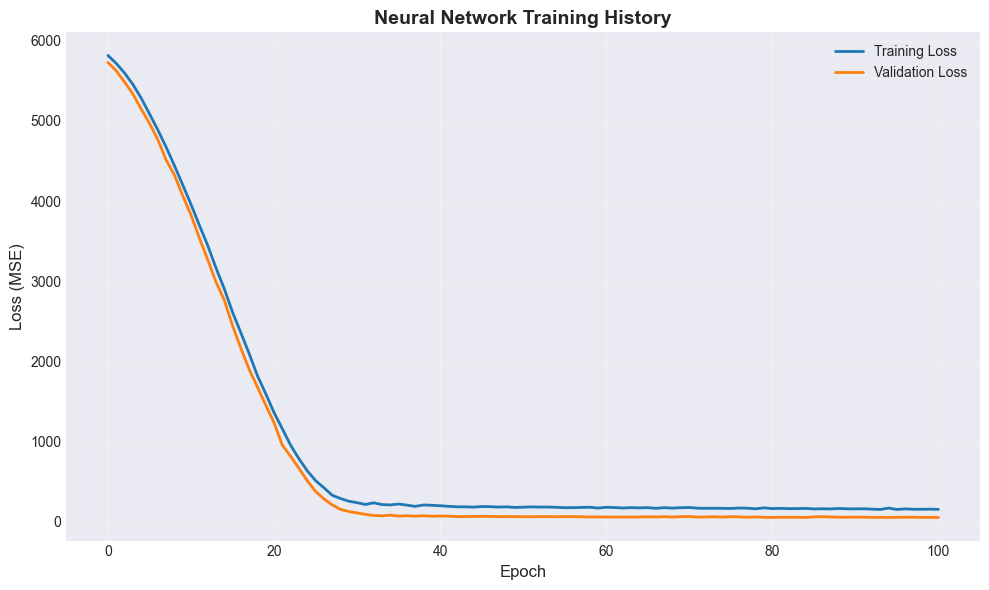

2025-10-08 19:50:42,357 - __main__ - INFO - Model comparison plot saved to output\model_comparison.png


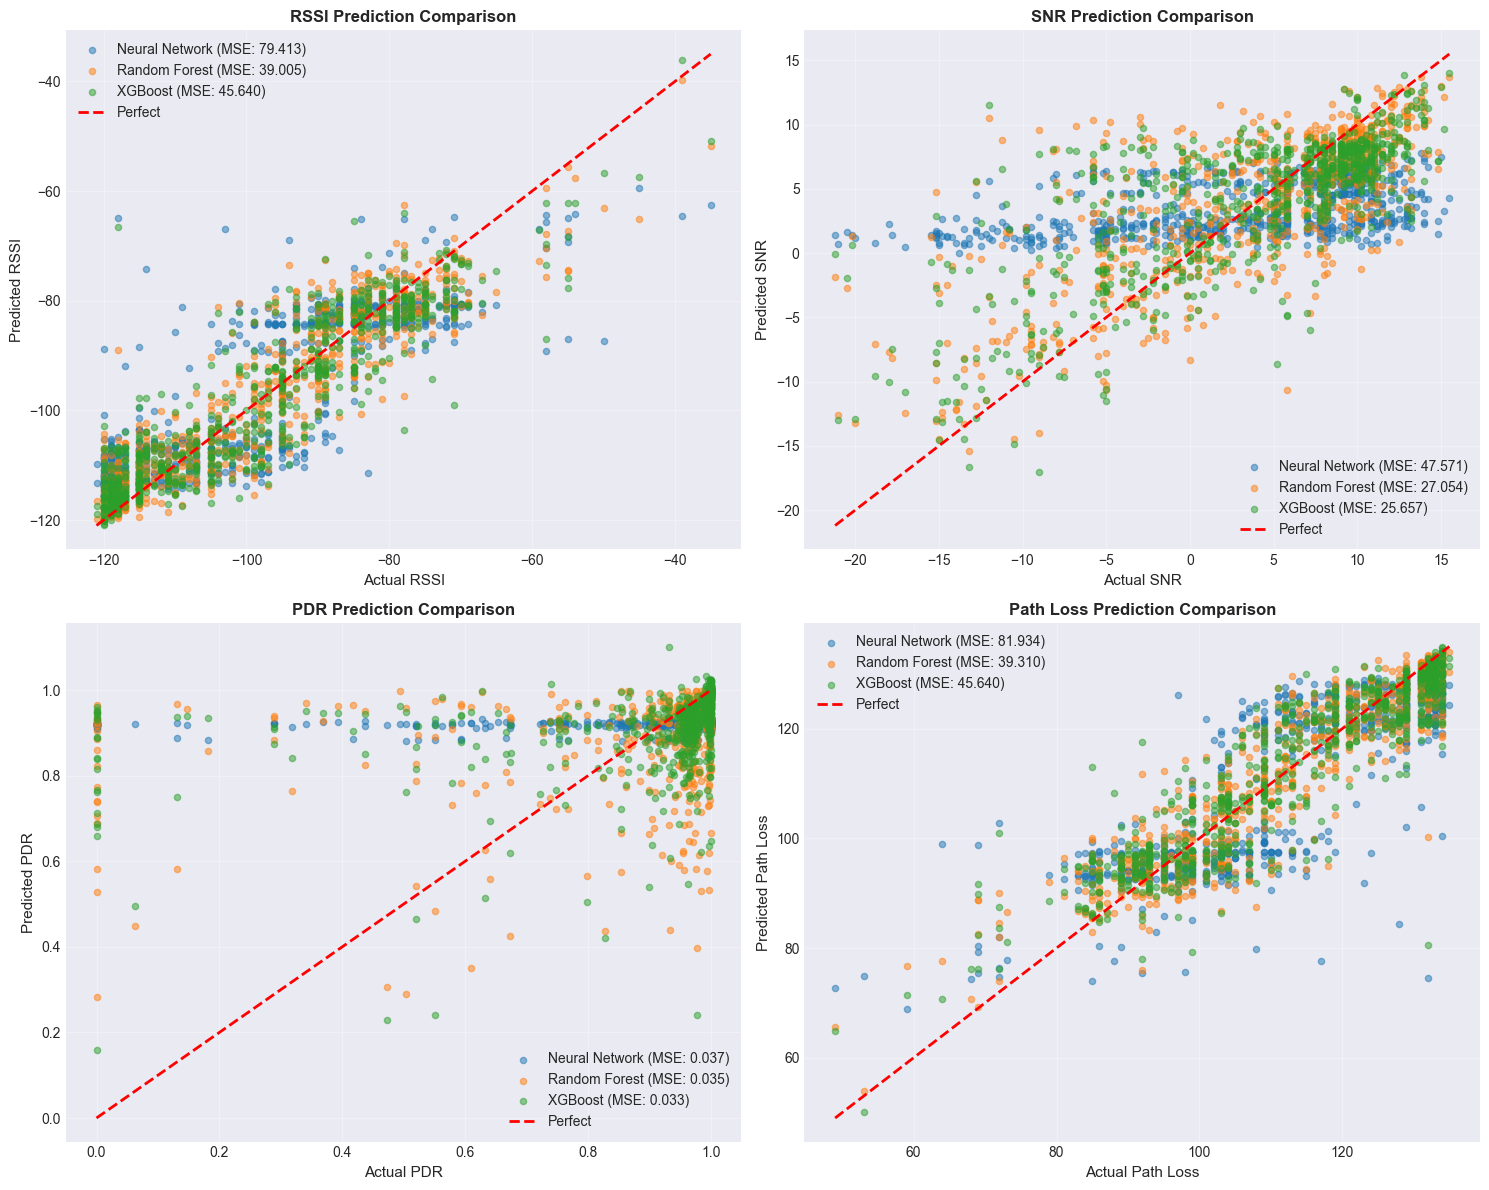

2025-10-08 19:50:42,803 - __main__ - INFO - 
2025-10-08 19:50:42,804 - __main__ - INFO - MODEL EVALUATION METRICS (MSE)
2025-10-08 19:50:42,804 - __main__ - INFO - ============================================================
2025-10-08 19:50:42,804 - __main__ - INFO - 
RSSI:
2025-10-08 19:50:42,805 - __main__ - INFO -   Neural Network       - MSE: 79.4125, MAE: 7.0577, R²: 0.7240
2025-10-08 19:50:42,806 - __main__ - INFO -   Random Forest        - MSE: 39.0051, MAE: 4.6234, R²: 0.8644
2025-10-08 19:50:42,806 - __main__ - INFO -   XGBoost              - MSE: 45.6401, MAE: 4.9932, R²: 0.8414
2025-10-08 19:50:42,806 - __main__ - INFO - 
SNR:
2025-10-08 19:50:42,807 - __main__ - INFO -   Neural Network       - MSE: 47.5715, MAE: 5.5876, R²: 0.1818
2025-10-08 19:50:42,808 - __main__ - INFO -   Random Forest        - MSE: 27.0539, MAE: 3.7534, R²: 0.5347
2025-10-08 19:50:42,809 - __main__ - INFO -   XGBoost              - MSE: 25.6571, MAE: 3.7169, R²: 0.5587
2025-10-08 19:50:42,809 - __main

Model evaluation completed
  - Generated: output/training_history.png
  - Generated: output/model_comparison.png


 4b. Saving Model Comparison to CSV...
  - Saved model comparison to: output/model_comparison.csv
  - Saved detailed predictions to: output/detailed_predictions.csv


 5. Running Path Optimization Example...
  Path: (40.7128, -74.0060) -> (40.7589, -73.9851)
  LoRa Parameters: SF=7, Freq=868.0MHz, TX Power=14.0dBm


2025-10-08 19:51:00,189 - __main__ - INFO -   Total distance: 5.42 km
2025-10-08 19:51:00,189 - __main__ - INFO -   Grid spacing: 0.55 km (actual: 0.60 km)
2025-10-08 19:51:00,190 - __main__ - INFO -   Grid size: 10x10 = 100 points
2025-10-08 19:51:00,191 - __main__ - INFO -   Estimated API calls: 100 (main grid)
2025-10-08 19:51:00,191 - __main__ - INFO - 
Fetching REAL spatial data from Google Earth Engine...
2025-10-08 19:51:00,192 - __main__ - INFO -   - Elevation from SRTM (30m resolution)
2025-10-08 19:51:00,193 - __main__ - INFO -   - Land cover from ESA WorldCover (10m resolution)
2025-10-08 19:51:00,193 - __main__ - INFO - Fetching spatial features for 100 locations...
2025-10-08 19:52:05,207 - __main__ - INFO - Progress: 50/100 (50.0%)
2025-10-08 19:52:57,407 - __main__ - INFO - Completed: 100/100 (100%)
2025-10-08 19:52:57,408 - __main__ - INFO - 
Predicting communication metrics with ML models...
2025-10-08 19:52:57,557 - __main__ - INFO - Predictions completed for 100 poin

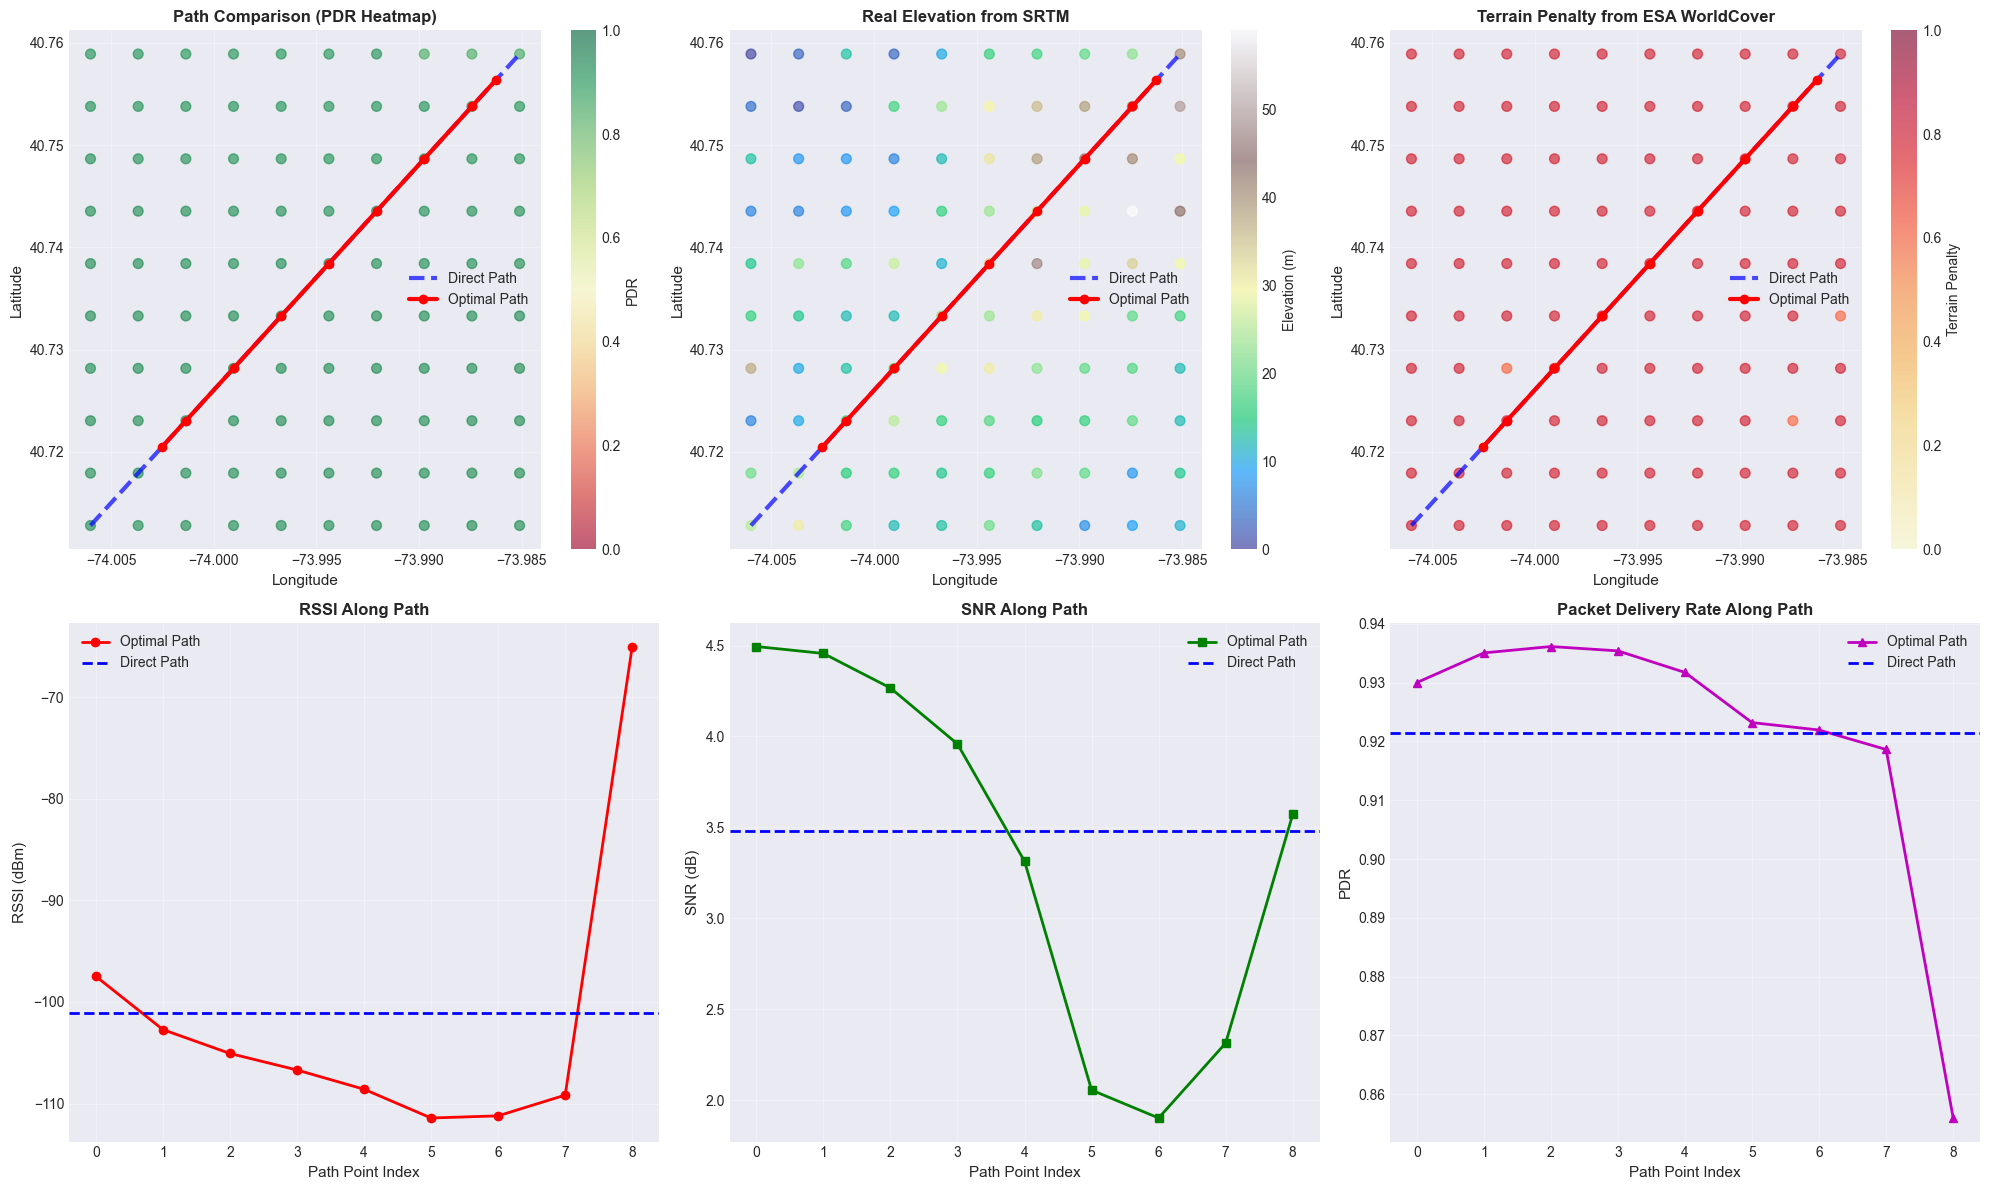

2025-10-08 19:53:36,977 - __main__ - INFO - 
Creating HTML visualization: path_optimization.html
2025-10-08 19:53:37,071 - __main__ - INFO - HTML map saved to output\path_optimization.html



PATH OPTIMIZATION SUMMARY

Direct Path:
  Average RSSI: -101.10 dBm
  Average SNR:  3.48 dB
  Average PDR:  0.9214 (92.14%)

Optimal Path:
  Average RSSI: -101.93 dBm
  Average SNR:  3.37 dB
  Average PDR:  0.9209 (92.09%)
  Path length:  9 waypoints
  Avg Elevation: 29.7 m (from SRTM)
  Avg Terrain Penalty: 0.800 (from ESA WorldCover)

Improvements:
  RSSI: -0.83 dBm (-0.83%)
  SNR:  -0.11 dB (-3.22%)
  PDR:  -0.05%

  - Saved optimal path to: output/optimal_path.csv
  - Saved direct path metrics to: output/direct_path_metrics.csv
  - Saved grid points to: output/grid_points.csv
Path optimization completed
  - Optimal path: 9 waypoints
  - Generated: output/path_comparison.png
  - Generated: output/path_optimization.html



SYSTEM EXECUTION COMPLETED SUCCESSFULLY

Generated Files:
  output/training_history.png - Neural network training progress
  output/model_comparison.png - Performance comparison of all models
  output/model_comparison.csv - Model metrics comparison (CSV)
  output/

In [13]:
def main():
    """Main function to run the complete LoRa path optimization system with REAL data"""
    print("="*60)
    print("LoRa Path Optimization System with Real Data")
    print("="*60)
    
    # Create output directory if it doesn't exist
    output_dir = Path("./output")
    output_dir.mkdir(exist_ok=True)
    
    # ========================================
    # STEP 1: INITIALIZE THE SYSTEM
    # ========================================
    print("\n\n 1. Initializing LoRa System...")
    
    # Create the main system object
    lora_system = LoRaSystem()
    
    # Check if Google Earth Engine is available
    if lora_system.gee.initialized:
        print("Google Earth Engine initialized successfully")
        print("  - Using real elevation data from SRTM (30m resolution)")
        print("  - Using real land cover data from ESA WorldCover (10m resolution)")
    else:
        print("Google Earth Engine not available - using simulated spatial data")
    
    # ========================================
    # STEP 2: LOAD AND PREPROCESS REAL DATA
    # ========================================
    print("\n\n 2. Loading and Preprocessing Real Data...")
    
    try:
        # Load real datasets
        X_train, X_test, y_train, y_test, feature_cols = lora_system.load_and_preprocess_data()
        print(f"Loaded {len(X_train)} training samples and {len(X_test)} test samples")
        print(f"Features: {feature_cols}")
        
    except Exception as e:
        print(f"Error loading real data: {e}")
        print("\nPlease ensure you have real data files in the '../data' directory:")
        print("  - processed_data_1.csv")
        print("  - processed_data_2.csv")
        print("\nYour real data should include these columns:")
        print("  Required: latitude, longitude, RSSI, SNR, PDR")
        print("  Optional: elevation, land_cover, terrain_penalty, spreading_factor, frequency, tx_power")
        print("  If missing, elevation/land_cover will be fetched from Google Earth Engine")
        return
    
    # ========================================
    # STEP 3: TRAIN MACHINE LEARNING MODELS
    # ========================================
    print("\n\n 3. Training Machine Learning Models...")
    
    try:
        # Train all three models: Neural Network, Random Forest, XGBoost
        train_result = lora_system.train_models(
            X_train, X_test, y_train, y_test, feature_cols
        )
        
        # Check how many values were returned
        if len(train_result) == 4:
            predictions_dict, y_test, feature_cols, nn_trainer = train_result
        else:
            # If not 4 values, unpack accordingly
            predictions_dict, y_test, feature_cols = train_result
            nn_trainer = None
            print("Warning: train_models did not return nn_trainer")
        
        print("Successfully trained all models")
        
    except Exception as e:
        print(f"Error training models: {e}")
        return
    
    # ========================================
    # STEP 4: EVALUATE MODELS
    # ========================================
    print("\n\n 4. Evaluating Model Performance...")
    
    try:
        # Compare model performances and generate visualizations
        lora_system.evaluate_models(predictions_dict, y_test, feature_cols, nn_trainer)
        print("Model evaluation completed")
        print(f"  - Generated: {output_dir}/training_history.png")
        print(f"  - Generated: {output_dir}/model_comparison.png")
        
    except Exception as e:
        print(f"Error evaluating models: {e}")
        return
    
    # ========================================
    # STEP 4b: SAVE MODEL COMPARISON TO CSV
    # ========================================
    print("\n\n 4b. Saving Model Comparison to CSV...")
    
    try:
        # Create model comparison dataframe
        comparison_data = []
        metrics = ['RSSI', 'SNR', 'PDR', 'Path Loss']
        
        for i, metric in enumerate(metrics):
            for model_name, predictions in predictions_dict.items():
                mse = np.mean((y_test[:, i] - predictions[:, i])**2)
                mae = np.mean(np.abs(y_test[:, i] - predictions[:, i]))
                rmse = np.sqrt(mse)
                r2 = 1 - np.sum((y_test[:, i] - predictions[:, i])**2) / np.sum((y_test[:, i] - np.mean(y_test[:, i]))**2)
                
                comparison_data.append({
                    'Metric': metric,
                    'Model': model_name,
                    'MSE': mse,
                    'RMSE': rmse,
                    'MAE': mae,
                    'R2_Score': r2
                })
        
        comparison_df = pd.DataFrame(comparison_data)
        comparison_df.to_csv(output_dir / 'model_comparison.csv', index=False)
        print(f"  - Saved model comparison to: {output_dir}/model_comparison.csv")
        
        # Also save detailed predictions
        predictions_detailed = pd.DataFrame({
            'Actual_RSSI': y_test[:, 0],
            'Actual_SNR': y_test[:, 1],
            'Actual_PDR': y_test[:, 2],
            'Actual_PathLoss': y_test[:, 3],
            'NN_RSSI': predictions_dict['Neural Network'][:, 0],
            'NN_SNR': predictions_dict['Neural Network'][:, 1],
            'NN_PDR': predictions_dict['Neural Network'][:, 2],
            'NN_PathLoss': predictions_dict['Neural Network'][:, 3],
            'RF_RSSI': predictions_dict['Random Forest'][:, 0],
            'RF_SNR': predictions_dict['Random Forest'][:, 1],
            'RF_PDR': predictions_dict['Random Forest'][:, 2],
            'RF_PathLoss': predictions_dict['Random Forest'][:, 3],
            'XGB_RSSI': predictions_dict['XGBoost'][:, 0],
            'XGB_SNR': predictions_dict['XGBoost'][:, 1],
            'XGB_PDR': predictions_dict['XGBoost'][:, 2],
            'XGB_PathLoss': predictions_dict['XGBoost'][:, 3],
        })
        predictions_detailed.to_csv(output_dir / 'detailed_predictions.csv', index=False)
        print(f"  - Saved detailed predictions to: {output_dir}/detailed_predictions.csv")
        
    except Exception as e:
        print(f"Error saving model comparison: {e}")
    
    # ========================================
    # STEP 5: PATH OPTIMIZATION
    # ========================================
    print("\n\n 5. Running Path Optimization Example...")
    
    try:
        # Define coordinates for path optimization
        start_lat, start_lon = 40.7128, -74.0060
        dest_lat, dest_lon = 40.7589, -73.9851
        
        # Define LoRa communication parameters
        lora_params = LoRaParameters(
            tx_power=14.0,
            spreading_factor=7,
            frequency=868.0,
            bandwidth=125.0,
            coding_rate=4
        )
        
        print(f"  Path: ({start_lat:.4f}, {start_lon:.4f}) -> ({dest_lat:.4f}, {dest_lon:.4f})")
        print(f"  LoRa Parameters: SF={lora_params.spreading_factor}, "
              f"Freq={lora_params.frequency}MHz, TX Power={lora_params.tx_power}dBm")
        
        # Create a wrapper for the neural network model
        class ModelWrapper:
            def __init__(self, model, device):
                self.model = model
                self.device = device
            def predict(self, X):
                self.model.eval()
                with torch.no_grad():
                    X_tensor = torch.FloatTensor(X).to(self.device)
                    predictions = self.model(X_tensor).cpu().numpy()
                return predictions
        
        # Initialize path optimizer
        wrapper = ModelWrapper(lora_system.models['neural_network'], lora_system.device)
        optimizer = PathOptimizer(
            wrapper, 
            lora_system.scalers['feature'], 
            feature_cols,
            lora_system.gee
        )
        
        # Run path optimization
        optimal_path, grid_points = optimizer.find_optimal_path(
            start_lat, start_lon, dest_lat, dest_lon,
            lora_params, OptimizationConfig()
        )
        
        # Sample direct path for comparison
        direct_path_metrics = optimizer.sample_direct_path(
            start_lat, start_lon, dest_lat, dest_lon, lora_params, num_samples=10
        )
        
        # ===== FIX: Generate visualizations (PNG and HTML) =====
        visualizer = ResultVisualizer()
        
        # Generate PNG visualization
        visualizer.plot_path_comparison(optimal_path, direct_path_metrics, grid_points)
        
        # Generate HTML interactive map
        visualizer.visualize_path_html(
            optimal_path, 
            direct_path_metrics, 
            grid_points,
            filename='path_optimization.html'
        )
        
        # Print summary
        visualizer.print_path_summary(optimal_path, direct_path_metrics)
        
        # Save optimal path to CSV
        optimal_path_data = []
        for i, point in enumerate(optimal_path):
            optimal_path_data.append({
                'point_id': i,
                'latitude': point.lat,
                'longitude': point.lon,
                'elevation': point.elevation,
                'land_cover': point.land_cover,
                'terrain_penalty': point.terrain_penalty,
                'distance_to_start': point.distance_to_start,
                'distance_to_destination': point.distance_to_destination,
                'RSSI': point.rssi,
                'SNR': point.snr,
                'PDR': point.pdr,
                'path_loss': point.path_loss
            })
        
        optimal_path_df = pd.DataFrame(optimal_path_data)
        optimal_path_df.to_csv(output_dir / 'optimal_path.csv', index=False)
        print(f"  - Saved optimal path to: {output_dir}/optimal_path.csv")
        
        # Save direct path metrics to CSV
        direct_path_df = pd.DataFrame([direct_path_metrics])
        direct_path_df.to_csv(output_dir / 'direct_path_metrics.csv', index=False)
        print(f"  - Saved direct path metrics to: {output_dir}/direct_path_metrics.csv")
        
        # Save grid points to CSV
        grid_data = []
        for i, point in enumerate(grid_points):
            grid_data.append({
                'point_id': i,
                'latitude': point.lat,
                'longitude': point.lon,
                'elevation': point.elevation,
                'land_cover': point.land_cover,
                'terrain_penalty': point.terrain_penalty,
                'RSSI': point.rssi,
                'SNR': point.snr,
                'PDR': point.pdr,
                'path_loss': point.path_loss
            })
        
        grid_df = pd.DataFrame(grid_data)
        grid_df.to_csv(output_dir / 'grid_points.csv', index=False)
        print(f"  - Saved grid points to: {output_dir}/grid_points.csv")
        
        print(f"Path optimization completed")
        print(f"  - Optimal path: {len(optimal_path)} waypoints")
        print(f"  - Generated: {output_dir}/path_comparison.png")
        print(f"  - Generated: {output_dir}/path_optimization.html")  # <=== ADDED
        
    except Exception as e:
        print(f"Error in path optimization: {e}")
        import traceback
        traceback.print_exc()
    """"
    # ========================================
    # STEP 6: MULTI-HOP ROUTING 
    # ========================================
    print("\n\n 6. Running Multi-hop Routing Example...")
    
    try:
        # Define longer distance for multi-hop
        far_lat, far_lon = 41.8781, -87.6298
        
        print(f"  Multi-hop path: ({start_lat:.4f}, {start_lon:.4f}) -> ({far_lat:.4f}, {far_lon:.4f})")
        
        # Initialize multi-hop router
        router = MultiHopRouter(
            wrapper,  # Use the same wrapper
            lora_system.scalers['feature'],
            feature_cols,
            lora_system.gee
        )
        
        # Run multi-hop routing
        multi_hop_path = router.find_relay_nodes(
            start_lat, start_lon, far_lat, far_lon,
            max_hop_distance_km=5.0,
            min_relay_distance_km=1.0,
            lora_params=lora_params,
            config=OptimizationConfig()
        )
        
        # Save multi-hop path to CSV
        all_hops_data = []
        for hop in multi_hop_path:
            for i, point in enumerate(hop['path']):
                all_hops_data.append({
                    'hop_number': hop['hop_number'],
                    'point_id': i,
                    'latitude': point.lat,
                    'longitude': point.lon,
                    'elevation': point.elevation,
                    'land_cover': point.land_cover,
                    'terrain_penalty': point.terrain_penalty,
                    'distance_to_start': point.distance_to_start,
                    'distance_to_destination': point.distance_to_destination,
                    'RSSI': point.rssi,
                    'SNR': point.snr,
                    'PDR': point.pdr,
                    'path_loss': point.path_loss,
                    'is_relay': point.is_relay
                })
        
        multi_hop_df = pd.DataFrame(all_hops_data)
        multi_hop_df.to_csv(output_dir / 'multi_hop_path.csv', index=False)
        print(f"  - Saved multi-hop path to: {output_dir}/multi_hop_path.csv")
        
        # ===== FIX: Visualize multi-hop path as HTML =====
        router.visualize_multi_hop(multi_hop_path, filename='multi_hop_routing.html')
        
        print(f"Multi-hop routing completed")
        print(f"  - Generated: {output_dir}/multi_hop_routing.html")  # <=== ADDED
        
    except Exception as e:
        print(f"Error in multi-hop routing: {e}")
        import traceback
        traceback.print_exc()
    
    # ========================================
    # STEP 7: COVERAGE MAP GENERATION
    # ========================================
    print("\n\n 7. Generating Coverage Map...")
    
    try:
        # Initialize coverage map generator
        coverage_generator = CoverageMapGenerator(
            lora_system.models['neural_network'],
            lora_system.scalers['feature'],
            feature_cols,
            lora_system.gee
        )
        
        # Generate coverage map around the start point
        coverage_data = coverage_generator.generate_coverage_map(
            center_lat=start_lat,
            center_lon=start_lon,
            lora_params=lora_params,
            radius_km=10,      # 10 km radius
            grid_resolution=30,  # 30x30 grid
            filename=str(output_dir / 'coverage_map.html')
        )
        
        # Coverage data is already saved to CSV in the generate_coverage_map method
        print(f"Coverage map generated")
        print(f"  - Grid: 30x30 = 900 points")
        print(f"  - Radius: 10 km")
        print(f"  - Generated: {output_dir}/coverage_map.html")
        print(f"  - Generated: {output_dir}/coverage_map_data.csv")
        
    except Exception as e:
        print(f"Error generating coverage map: {e}")
    """
    # ========================================
    # STEP 8: FINAL SUMMARY
    # ========================================
    print("\n\n\n" + "="*60)
    print("SYSTEM EXECUTION COMPLETED SUCCESSFULLY")
    print("="*60)
    print("\nGenerated Files:")
    print(f"  {output_dir}/training_history.png - Neural network training progress")
    print(f"  {output_dir}/model_comparison.png - Performance comparison of all models")
    print(f"  {output_dir}/model_comparison.csv - Model metrics comparison (CSV)")
    print(f"  {output_dir}/detailed_predictions.csv - Detailed predictions (CSV)")
    print(f"  {output_dir}/path_comparison.png - Optimal vs direct path visualization")
    print(f"  {output_dir}/path_optimization.html - Interactive optimized path map")
    print(f"  {output_dir}/multi_hop_routing.html - Interactive multi-hop routing map")
    print(f"  {output_dir}/coverage_map.html - Signal coverage heatmap")
    print(f"  {output_dir}/coverage_map_data.csv - Coverage data in CSV format")
    print(f"  {output_dir}/optimal_path.csv - Optimal path points with metrics")
    print(f"  {output_dir}/direct_path_metrics.csv - Direct path metrics")
    print(f"  {output_dir}/grid_points.csv - All evaluated grid points")
    print(f"  {output_dir}/multi_hop_path.csv - Multi-hop path points with metrics")
    print("\n" + "="*60)

# ========================================
# EXECUTE THE MAIN FUNCTION
# ========================================
if __name__ == "__main__":
    # Run the complete system
    main()